# Data Mining II (Spring Semester 2025-2026)
---
## Project: Reach for Change | Predicting Donor Response to Optimize Outreach for Social Good
**Group:** TBD  
**Authors:**
* João Galamba - 20250131
* Tamara Arakelyan - 20250290
* Thiago Bellas - 20231131

---


## <b><span style='color:#e61227'></span>Predicting Donor Response to Optimize Outreach for Social Good</b>


# <b><span style='color:#e61227'></span> Introduction<b>


## <b><span style='color:#e61227'></span> Purpose<b>

The main goal of this project is to predict whether a donor will respond positively to a future campaign, while keeping the full modeling workflow transparent and reproducible. The metodology follows a strict separation between **training**, **validation**, and **internal test** data. This design was chosen to avoid optimistic model selection and to make the final performance estimate more credible.

The independent Kaggle test file is only used after model development is complete, exactly as expected in a realistic deployment setting.


## <b><span style='color:#e61227'></span> What this notebook aims to demonstrate<b>

1. A clear and justified preprocessing strategy.
2. A concise but meaningful exploratory analysis **focused on decision-making**.
3. A classification pipeline based on methods and algorithms covered in class with an extra implementation in preprocessing using pipelines as a strategy for controlling and optimizing development code..
4. A model assessment strategy aligned with the project guidelines and the Kaggle F1 objective.
5. A transparent optimization procedure that includes both hyperparameter tuning and probability-threshold selection, in this case, threshold tuning is used for a better model fit.
6. An open-ended analytical section that goes beyond simply fitting a predictive pipeline.



## <b><span style='color:#e61227'></span> Methodological summary<b>

- **Input data**: `donors_train.csv` for model development and `donors_test.csv` for final prediction.
- **Target**: `TARGET_B`.
- **Identifier excluded from modeling**: `CONTROL_NUMBER`.
- **Assessment design**: internal **train / validation / test** split.
- **Selection metric**: **F1 score**, because the competition is ranked with binary F1 and the class distribution is imbalanced.
- **Candidate models**: Logistic Regression, Decision Tree, Random Forest, and Extra Trees.
- **Final deployment step**: refit the chosen configuration on train + validation, freeze the validation-selected threshold, and produce Kaggle predictions for the unseen test file.



# <b><span style='color:#e61227'></span> Project Development<b>

### <b><span style='color:#e61227'></span> Reading guide<b>

Each section starts with a short statement of purpose, followed by code and then interpretation.

The notebook is intentionally written so that a first-time reader can understand not only **what** is done, but also **why** each decision was made.


---


## <b><span style='color:#e61227'></span> 1. Imports and notebook global configuration<b>

This section gathers all libraries, metrics, and global constants used throughout the notebook.

### <b><span style='color:#e61227'></span> Why centralize imports?<b>

Centralizing imports improves readability and reproducibility. A reviewer should be able to inspect one cell and immediately understand:

- which packages are required,
- which modeling families are being considered,
- which evaluation metrics drive the project,
- and which random seed ensures reproducibility.

### <b><span style='color:#e61227'></span> Design principles followed here<b>

- Only **vanilla scikit-learn** models and utilities are used, which keeps the notebook aligned with the project restrictions.
- The configuration uses a fixed `RANDOM_STATE` so that splits and algorithms can be replicated.
- Performance metrics are imported explicitly instead of being called indirectly, making the evaluation protocol transparent.
- Plot defaults are configured once to keep visual output consistent and uncluttered.



In [0]:
# Silence non-critical warnings to keep notebook output readable during presentation.
import warnings
warnings.filterwarnings('ignore')

# Core scientific Python stack.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities for mixed-type preprocessing and reproducible pipelines.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV

# Metrics selected to support threshold-dependent and threshold-independent assessment.
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Model inspection utility used in the open-ended section.
from sklearn.inspection import permutation_importance

# Candidate algorithms explored in the benchmark.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Global constants used throughout the notebook for reproducibility and readability.
RANDOM_STATE = 42
TARGET = 'TARGET_B'
ID_COL = 'CONTROL_NUMBER'

# Plot configuration chosen for consistent visual output.
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True



## <b><span style='color:#e61227'></span> 2. Loading the real project data<b>

The first operational step is to read the original CSV files supplied for the project.

`donors_train.csv`

`donors_test.csv`

### <b><span style='color:#e61227'></span> Why start from the raw files?<b>

For reproducibility, it is important that the notebook begins from the real data sources rather than from an already processed object. This makes the workflow auditable from the first step and helps verify that:

- the notebook can run end to end,
- the same logic is applied every time,
- and no hidden preprocessing is occurring outside the notebook.

At this stage we only inspect the dataset dimensions and preview a few rows. This is enough to confirm that the files were loaded correctly, without mixing exploration and preprocessing too early.



In [0]:
# Define the file paths for the labeled development data and the unlabeled Kaggle test data.
train_path = 'donors_train.csv'
test_path = 'donors_test.csv'

# Load the original CSV files exactly as provided for the project.
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Quick structural validation: dimensions should be consistent with expectations.
print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

train_df.head(30)


Train shape: (13560, 41)
Test shape : (5812, 40)


,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
0,61745,4.0,3.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,35.00,2.0,20.0,15.00,21.0,566.0,315.0,182.037132,18.00000,18.0,10.000000,0.0,52.000000,17.0,25.0,92.0,0.0,12827.0,A,0.000000,17.50,NaN,0.000,2.0,0.154000,0.000000,2,T,NaN,1
1,112703,3.0,2.000000,NaN,F,1.0,1.0,U,NaN,15.0,6.0,15.00,1.0,15.0,15.00,15.0,318.0,148.0,24.000000,24.00000,24.0,7.000000,0.0,31.000000,31.0,39.0,73.0,0.0,7787.0,N,15.000000,15.00,1.0,0.250,1.0,0.100000,0.000000,3,R,NaN,1
2,166437,4.0,2.000000,NaN,F,7.0,3.0,H,4.0,10.0,17.0,79.00,11.0,12.0,5.00,40.0,1669.0,373.0,129.000000,15.00000,15.0,8.000000,0.0,26.000000,39.0,38.0,84.0,1.0,13965.0,S,0.000000,10.67,0.0,0.000,3.0,0.231000,1.000000,1,U,NaN,0
3,170621,4.0,NaN,61.0,M,13.0,1.0,H,6.0,11.0,28.0,80.00,17.0,11.0,3.00,75.0,1464.0,488.0,130.000000,16.00000,16.0,13.000000,0.0,48.000000,30.0,44.0,84.0,1.0,24123.0,A,10.000000,10.00,2.0,0.286,2.0,0.111000,0.000000,1,U,NaN,0
4,44428,6.0,0.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,27.00,5.0,7.0,5.00,22.0,936.0,249.0,24.000000,17.00000,17.0,13.000000,0.0,52.000000,NaN,66.0,90.0,1.0,15008.0,N,5.670000,5.40,3.0,0.600,5.0,0.500000,0.000000,2,C,NaN,0
5,80221,5.0,0.000000,51.0,M,12.0,1.0,U,2.0,11.0,24.0,129.00,18.0,11.0,3.00,67.0,470.0,308.0,85.000000,17.00000,17.0,12.000000,0.0,20.000000,43.0,NaN,87.0,1.0,10616.0,A,9.670000,9.67,3.0,0.333,3.0,0.167000,6.000000,2,NaN,4.0,0
6,171942,6.0,3.000000,40.0,F,2.0,4.0,H,5.0,5.0,18.0,93.00,14.0,10.0,4.00,45.0,824.0,221.0,55.000000,15.00000,15.0,13.000000,0.0,29.000000,39.0,30.0,55.0,0.0,8428.0,A,9.000000,6.20,1.0,0.091,5.0,0.238000,0.000000,3,U,1.0,0
7,29567,3.0,0.000000,NaN,M,12.0,3.0,U,NaN,5.0,19.0,91.07,20.0,7.0,0.07,48.0,766.0,NaN,128.000000,17.00000,17.0,6.000000,0.0,20.000000,56.0,0.0,84.0,1.0,19881.0,S,4.670000,4.75,3.0,0.500,4.0,0.333000,1.000000,2,T,5.0,0
8,37885,6.0,4.000000,69.0,F,2.0,2.0,H,6.0,20.0,18.0,105.00,7.0,20.0,5.00,46.0,520.0,217.0,182.037132,16.00000,16.0,15.000000,0.0,4.000000,25.0,0.0,57.0,0.0,7811.0,A,20.000000,18.75,2.0,0.182,4.0,0.182000,0.000000,4,U,1.0,0
9,81374,6.0,4.000000,51.0,M,5.0,2.0,U,2.0,12.0,21.0,93.00,13.0,12.0,3.00,52.0,401.0,247.0,64.000000,NaN,19.0,13.000000,0.0,24.000000,30.0,25.0,83.0,1.0,9226.0,S,8.000000,10.00,1.0,0.111,3.0,0.150000,1.000000,3,R,2.0,0


In [0]:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CONTROL_NUMBER,13560.0,NaN,NaN,NaN,96433.007743,55926.026991,5.0,47975.25,97023.0,145252.75,191775.0
CARD_PROM_12,13297.0,NaN,NaN,NaN,5.379945,1.31719,1.0,5.0,6.0,6.0,17.0
CHILDREN,13298.0,NaN,NaN,NaN,1.996802,1.466203,-2.299824,1.0,2.0,3.0,6.220526
DONOR_AGE,10006.0,NaN,NaN,NaN,58.814086,17.568008,0.0,46.0,60.0,73.0,108.94645
DONOR_GENDER,13288,3,F,7230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FILE_CARD_GIFT,13300.0,NaN,NaN,NaN,5.242995,4.833704,-10.09857,2.0,4.0,8.0,32.0
FREQUENCY_STATUS_97NK,13278.0,NaN,NaN,NaN,1.993986,1.147577,-1.363824,1.0,2.0,3.0,5.279946
HOME_OWNER,13274,2,H,7233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCOME_GROUP,10271.0,NaN,NaN,NaN,3.923575,1.957765,-1.737977,2.0,4.0,5.0,9.50328
LAST_GIFT_AMT,13299.0,NaN,NaN,NaN,16.639062,12.952247,-21.8336,10.0,15.0,20.0,450.0


## <b><span style='color:#e61227'></span> 3. Exploratory data analysis (EDA) and rule-based data cleaning<b>

Before building the model, we identified that the project needs a data-quality check. In this dataset, several variables represent counts, elapsed months, percentages, or gift amounts. Those semantic roles imply natural domain constraints. If such constraints are violated, the modeling pipeline may learn from artifacts rather than donor behavior.

### Why place this section before modeling?

This step is intentionally positioned early because it serves two objectives at once:

1. **Exploratory diagnosis** - understand what kinds of quality issues exist in the raw files.
2. **Defensible cleaning** - correct only what can be justified by clear domain logic, without using target information.

### Cleaning philosophy adopted in this notebook

The goal is **not** to aggressively manipulate the data until it looks perfect. Instead, our approach is applies a conservative strategy:

- obvious placeholders such as `?` are converted to genuine missing values,
- impossible values are replaced with `NaN` rather than guessed,
- discrete variables are kept discrete,
- contradictory donor-history relationships are flagged and neutralized,
- and every rule is documented so that the preprocessing remains explainable.

Our concern is be very transparent giving priority to methodological clarity and avoids introducing undocumented assumptions.

### What the diagnostic will explicitly check

The audit below reproduces the main discrepancies identified in the raw training data and converts them into a structured quality report.

#### 1. Missingness profile
Some variables contain substantial missingness, especially socio-economic descriptors such as wealth, income group, and donor age. This matters because dropping incomplete rows would waste too much data.

#### 2. Impossible negative values
Variables such as donation counts, gift amounts, elapsed months, and per-capita income should not be negative in this business context. Negative values are therefore treated as invalid observations, not as meaningful signal.

#### 3. Percentages outside the 0–100 range
Percentage-style variables should remain within a closed interval. Values below 0 or above 100 are treated as data-quality failures.

#### 4. Discrete variables stored with decimal values
Several variables appear to encode counts, ratings, or ordinal groups. For those columns, non-integer values are suspicious. The notebook uses a two-part rule: values that are numerically very close to an integer are rounded, while genuinely fractional values are set to missing.

#### 5. Logical contradictions across related variables
Donation-history fields should be internally coherent. For example, the minimum lifetime gift cannot exceed the maximum lifetime gift; the last gift cannot exceed the lifetime maximum; and the number of recent card responses cannot exceed the total number of recent responses.

### Why convert invalid values to `NaN` instead of forcing corrections?

Because most contradictions do not reveal the correct value. Replacing them with `NaN` is more honest than fabricating a number, and the downstream pipelines already include imputation in a leakage-safe way.



In [0]:
# Create immutable copies of the raw files so that the audit remains reproducible.
train_raw = train_df.copy()
test_raw = test_df.copy()

In [0]:
# Standardize obvious placeholder missing values indentified in .cvs analisys done previously before auditing.
placeholder_tokens = ['?', 'NA', 'N/A', '', ' ']
train_raw = train_raw.replace(placeholder_tokens, np.nan)
test_raw = test_raw.replace(placeholder_tokens, np.nan)

In [0]:
train_raw.head(20)

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
0,61745,4.0,3.0,33.0,M,0.0,1.0,H,5.0,20.0,9.0,35.00,2.0,20.0,15.00,21.0,566.0,315.0,182.037132,18.0,18.0,10.0,0.0,52.000000,17.0,25.0,92.0,0.0,12827.0,A,0.00,17.50,NaN,0.000,2.0,0.154000,0.0,2,T,NaN,1
1,112703,3.0,2.0,NaN,F,1.0,1.0,U,NaN,15.0,6.0,15.00,1.0,15.0,15.00,15.0,318.0,148.0,24.000000,24.0,24.0,7.0,0.0,31.000000,31.0,39.0,73.0,0.0,7787.0,N,15.00,15.00,1.0,0.250,1.0,0.100000,0.0,3,R,NaN,1
2,166437,4.0,2.0,NaN,F,7.0,3.0,H,4.0,10.0,17.0,79.00,11.0,12.0,5.00,40.0,1669.0,373.0,129.000000,15.0,15.0,8.0,0.0,26.000000,39.0,38.0,84.0,1.0,13965.0,S,0.00,10.67,0.0,0.000,3.0,0.231000,1.0,1,U,NaN,0
3,170621,4.0,NaN,61.0,M,13.0,1.0,H,6.0,11.0,28.0,80.00,17.0,11.0,3.00,75.0,1464.0,488.0,130.000000,16.0,16.0,13.0,0.0,48.000000,30.0,44.0,84.0,1.0,24123.0,A,10.00,10.00,2.0,0.286,2.0,0.111000,0.0,1,U,NaN,0
4,44428,6.0,0.0,75.0,M,3.0,4.0,H,3.0,7.0,9.0,27.00,5.0,7.0,5.00,22.0,936.0,249.0,24.000000,17.0,17.0,13.0,0.0,52.000000,NaN,66.0,90.0,1.0,15008.0,N,5.67,5.40,3.0,0.600,5.0,0.500000,0.0,2,C,NaN,0
5,80221,5.0,0.0,51.0,M,12.0,1.0,U,2.0,11.0,24.0,129.00,18.0,11.0,3.00,67.0,470.0,308.0,85.000000,17.0,17.0,12.0,0.0,20.000000,43.0,NaN,87.0,1.0,10616.0,A,9.67,9.67,3.0,0.333,3.0,0.167000,6.0,2,NaN,4.0,0
6,171942,6.0,3.0,40.0,F,2.0,4.0,H,5.0,5.0,18.0,93.00,14.0,10.0,4.00,45.0,824.0,221.0,55.000000,15.0,15.0,13.0,0.0,29.000000,39.0,30.0,55.0,0.0,8428.0,A,9.00,6.20,1.0,0.091,5.0,0.238000,0.0,3,U,1.0,0
7,29567,3.0,0.0,NaN,M,12.0,3.0,U,NaN,5.0,19.0,91.07,20.0,7.0,0.07,48.0,766.0,NaN,128.000000,17.0,17.0,6.0,0.0,20.000000,56.0,0.0,84.0,1.0,19881.0,S,4.67,4.75,3.0,0.500,4.0,0.333000,1.0,2,T,5.0,0
8,37885,6.0,4.0,69.0,F,2.0,2.0,H,6.0,20.0,18.0,105.00,7.0,20.0,5.00,46.0,520.0,217.0,182.037132,16.0,16.0,15.0,0.0,4.000000,25.0,0.0,57.0,0.0,7811.0,A,20.00,18.75,2.0,0.182,4.0,0.182000,0.0,4,U,1.0,0
9,81374,6.0,4.0,51.0,M,5.0,2.0,U,2.0,12.0,21.0,93.00,13.0,12.0,3.00,52.0,401.0,247.0,64.000000,NaN,19.0,13.0,0.0,24.000000,30.0,25.0,83.0,1.0,9226.0,S,8.00,10.00,1.0,0.111,3.0,0.150000,1.0,3,R,2.0,0


In [0]:
# Variable groups derived from domain meaning.
non_negative_cols = [
    'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT', 'INCOME_GROUP',
    'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT',
    'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'MONTHS_SINCE_FIRST_GIFT',
    'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12',
    'CARD_PROM_12', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT',
    'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_PROP',
    'RECENT_RESPONSE_PROP', 'LAST_GIFT_AMT', 'PEP_STAR', 'WEALTH_RATING',
    'PER_CAPITA_INCOME'
]

percent_cols = [
    'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3',
    'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED'
]

discrete_cols = [
    'CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT',
    'FREQUENCY_STATUS_97NK', 'INCOME_GROUP', 'LIFETIME_CARD_PROM',
    'LIFETIME_GIFT_COUNT', 'LIFETIME_PROM', 'MONTHS_SINCE_LAST_GIFT',
    'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PEP_STAR',
    'RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT', 'RECENT_STAR_STATUS',
    'WEALTH_RATING'
]

categorical_unknown_map = {
    'DONOR_GENDER': ['U'],
    'HOME_OWNER': ['U'],
    'SES': ['?'],
    'URBANICITY': ['?']
}

In [0]:
# Create a function to ensure the columns inspected as numeric are indeed numeric when possible.
def force_numeric(df, columns):
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out


In [0]:
# Run the function on the raw data
train_raw = force_numeric(train_raw, sorted(set(non_negative_cols + percent_cols + discrete_cols + [
    'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT', 'LAST_GIFT_AMT',
    'LIFETIME_GIFT_AMOUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_CARD_RESPONSE_COUNT',
    'RECENT_RESPONSE_COUNT', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT'
])))

In [0]:
# Here we create a function to implement a deterministic Data Quality Audit.
def audit_data_quality(df):
    rows = []

    # Missingness by column.
    missing_pct = df.isna().mean().mul(100)
    for col, pct in missing_pct[missing_pct > 0].sort_values(ascending=False).items():
        rows.append({'issue_type': 'missing_values', 'column': col, 'count': int(df[col].isna().sum()), 'detail': f'{pct:.2f}% missing'})

    # Negative values in columns expected to be non-negative.
    for col in non_negative_cols:
        if col in df.columns:
            mask = df[col].notna() & (df[col] < 0)
            if mask.any():
                rows.append({'issue_type': 'negative_value', 'column': col, 'count': int(mask.sum()), 'detail': 'Value below 0 in a non-negative field'})

    # Percentages outside domain.
    for col in percent_cols:
        if col in df.columns:
            mask = df[col].notna() & ((df[col] < 0) | (df[col] > 100))
            if mask.any():
                rows.append({'issue_type': 'percentage_out_of_range', 'column': col, 'count': int(mask.sum()), 'detail': 'Expected interval is [0, 100]'})

    # Decimal values in discrete columns.
    for col in discrete_cols:
        if col in df.columns:
            mask = df[col].notna() & ~np.isclose(df[col], np.round(df[col]), atol=1e-6)
            if mask.any():
                rows.append({'issue_type': 'non_integer_discrete_value', 'column': col, 'count': int(mask.sum()), 'detail': 'Discrete-looking field contains fractional values'})

    # Logical contradictions.
    contradiction_rules = {
        'min_greater_than_max': df['LIFETIME_MIN_GIFT_AMT'].notna() & df['LIFETIME_MAX_GIFT_AMT'].notna() & (df['LIFETIME_MIN_GIFT_AMT'] > df['LIFETIME_MAX_GIFT_AMT']),
        'last_greater_than_lifetime_max': df['LAST_GIFT_AMT'].notna() & df['LIFETIME_MAX_GIFT_AMT'].notna() & (df['LAST_GIFT_AMT'] > df['LIFETIME_MAX_GIFT_AMT']),
        'lifetime_amount_less_than_last': df['LIFETIME_GIFT_AMOUNT'].notna() & df['LAST_GIFT_AMT'].notna() & (df['LIFETIME_GIFT_AMOUNT'] < df['LAST_GIFT_AMT']),
        'lifetime_amount_less_than_lifetime_max': df['LIFETIME_GIFT_AMOUNT'].notna() & df['LIFETIME_MAX_GIFT_AMT'].notna() & (df['LIFETIME_GIFT_AMOUNT'] < df['LIFETIME_MAX_GIFT_AMT']),
        'recent_card_count_greater_than_recent_count': df['RECENT_CARD_RESPONSE_COUNT'].notna() & df['RECENT_RESPONSE_COUNT'].notna() & (df['RECENT_CARD_RESPONSE_COUNT'] > df['RECENT_RESPONSE_COUNT']),
        'months_last_gift_greater_than_months_first_gift': df['MONTHS_SINCE_LAST_GIFT'].notna() & df['MONTHS_SINCE_FIRST_GIFT'].notna() & (df['MONTHS_SINCE_LAST_GIFT'] > df['MONTHS_SINCE_FIRST_GIFT']),
        'months_last_promo_response_greater_than_months_first_gift': df['MONTHS_SINCE_LAST_PROM_RESP'].notna() & df['MONTHS_SINCE_FIRST_GIFT'].notna() & (df['MONTHS_SINCE_LAST_PROM_RESP'] > df['MONTHS_SINCE_FIRST_GIFT']),
        'recent_avg_gift_zero_with_recent_response': df['RECENT_AVG_GIFT_AMT'].notna() & df['RECENT_RESPONSE_COUNT'].notna() & (df['RECENT_AVG_GIFT_AMT'] == 0) & (df['RECENT_RESPONSE_COUNT'] > 0),
        'recent_avg_card_gift_zero_with_recent_card_response': df['RECENT_AVG_CARD_GIFT_AMT'].notna() & df['RECENT_CARD_RESPONSE_COUNT'].notna() & (df['RECENT_AVG_CARD_GIFT_AMT'] == 0) & (df['RECENT_CARD_RESPONSE_COUNT'] > 0),
    }
    for name, mask in contradiction_rules.items():
        if mask.any():
            rows.append({'issue_type': 'logical_contradiction', 'column': 'multiple', 'count': int(mask.sum()), 'detail': name})

    return pd.DataFrame(rows).sort_values(['issue_type', 'count'], ascending=[True, False]).reset_index(drop=True)

In [0]:
# Applaying Deterministic DQ
quality_report = audit_data_quality(train_raw)

# Compact summary.
headline = pd.Series({
    'n_rows': len(train_raw),
    'n_columns': train_raw.shape[1],
    'duplicate_CONTROL_NUMBER': int(train_raw['CONTROL_NUMBER'].duplicated().sum()),
    'positive_class_rate': round(train_raw[TARGET].mean(), 4)
}, name='value')

print(headline)


n_rows                      13560.00
n_columns                      41.00
duplicate_CONTROL_NUMBER        0.00
positive_class_rate             0.25
Name: value, dtype: float64


In [0]:
print('Top data-quality findings:')
display(quality_report.head(20))

Top data-quality findings:


issue_type,column,count,detail
logical_contradiction,multiple,126,min_greater_than_max
logical_contradiction,multiple,124,last_greater_than_lifetime_max
logical_contradiction,multiple,119,recent_card_count_greater_than_recent_count
logical_contradiction,multiple,92,lifetime_amount_less_than_lifetime_max
logical_contradiction,multiple,88,lifetime_amount_less_than_last
logical_contradiction,multiple,82,months_last_promo_response_greater_than_months_first_gift
logical_contradiction,multiple,79,months_last_gift_greater_than_months_first_gift
logical_contradiction,multiple,11,recent_avg_card_gift_zero_with_recent_card_response
logical_contradiction,multiple,1,recent_avg_gift_zero_with_recent_response
missing_values,WEALTH_RATING,6270,46.24% missing


## <b><span style='color:#e61227'></span> 4. Audited cleaning and leakage-aware split design<b>

The previous subsection identified invalid values, but diagnosis alone is not enough. We now translate those findings into a **rule-based cleaning stage** that can be justified without looking at the target.

### Why this cleaning can be applied before the split

The rules below do **not** estimate parameters from the full dataset and do **not** use `TARGET_B`. They simply enforce domain validity:

- replace placeholders with missing values,
- neutralize impossible negatives,
- constrain percentages to their legal range,
- preserve the discrete nature of count/ordinal variables,
- and remove direct contradictions in donor-history fields.

Claro — aqui está em inglês nível B2:

Before splitting the data, an initial cleaning step was carried out using simple and objective data quality rules. These rules did not calculate any parameters from the full dataset and did not use information from the target variable.

For this reason, this step can be understood more as a check of the meaning and consistency of the data, rather than as statistical preprocessing. The transformations that depend on the data distribution, such as missing value imputation and normalization, were fitted only on the training data and then applied to the validation and test sets. In this way, the necessary care was taken to avoid information leakage between the data partitions.


### Why keep invalid values as missing?

Once an observation is known to be "impossible", the safest option is to mark it as unknown and let the downstream imputation strategy handle it within the training folds. This keeps the cleaning step conservative and reproducible.



In [0]:
# Deterministic cleanning function
# Instead of cleaning the dataset ad hoc, a single, replicable function was created.
# This improves consistency, auditability, and reduces the risk of discrepancies between training and test data.

## This function performs deterministic, rule-based cleaning. It standardizes missing-value placeholders, invalidates impossible numeric values, preserves the discrete nature of count-like variables, neutralizes logical contradictions across related donor-history fields, and records every intervention in a cleaning log. The goal is not to guess the correct value, but to convert unreliable values into missing data so they can be handled later in a proper preprocessing pipeline.

def clean_donors_frame(df):
    cleaned = df.copy() # the dataframe already cleaned, it makes a copy and works on that copy.
    cleaning_log = []   # A table recording what was changed, that is:
                        #     * which rule was applied
                        #     * how many cells or rows were affected

    # Standardize explicit placeholder tokens. Looking "?", "NA", "N/A" empty strings and transform in NaN
    before_missing = int(cleaned.isna().sum().sum())
    cleaned = cleaned.replace(placeholder_tokens, np.nan)
    after_missing = int(cleaned.isna().sum().sum())
    cleaning_log.append({'rule': 'placeholder_to_nan', 'affected_cells': after_missing - before_missing})

    # Normalize ambiguous categorical codes. Some categorical columns have dubious codes such as "U" and "?" ti will be converted to NaN
    for col, bad_tokens in categorical_unknown_map.items():
        if col in cleaned.columns:
            mask = cleaned[col].isin(bad_tokens)
            cleaning_log.append({'rule': f'unknown_category_to_nan::{col}', 'affected_cells': int(mask.sum())})
            cleaned.loc[mask, col] = np.nan

    # Numeric coercion for the columns audited by business logic.
    # There is a set of columns that need to be read as numbers. The function forces these columns to be numeric.
    numeric_targets = sorted(set(non_negative_cols + percent_cols + discrete_cols + [
        'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT', 'LAST_GIFT_AMT',
        'LIFETIME_GIFT_AMOUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_CARD_RESPONSE_COUNT',
        'RECENT_RESPONSE_COUNT', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT'
    ]))
    cleaned = force_numeric(cleaned, numeric_targets)

    # Rule 1: values that cannot be negative become missing.
    for col in non_negative_cols:
        if col in cleaned.columns:
            mask = cleaned[col].notna() & (cleaned[col] < 0)
            cleaning_log.append({'rule': f'negative_to_nan::{col}', 'affected_cells': int(mask.sum())})
            cleaned.loc[mask, col] = np.nan

    # Rule 2: percentages must stay within the [0, 100] interval. When a percentage falls outside the possible range, it is considered NaN.
    for col in percent_cols:
        if col in cleaned.columns:
            mask = cleaned[col].notna() & ((cleaned[col] < 0) | (cleaned[col] > 100))
            cleaning_log.append({'rule': f'percent_out_of_range_to_nan::{col}', 'affected_cells': int(mask.sum())})
            cleaned.loc[mask, col] = np.nan

    # Rule 3: keep discrete variables discrete. If the variable should be an integer and the value is almost an integer, we correct it. If it is actually fractional, we assume the value is inconsistent.
    # Near-integers are rounded to preserve information when the discrepancy is likely numerical noise.
    # Clearly fractional values are removed because their true category/count is unknowable.
    for col in discrete_cols:
        if col in cleaned.columns:
            near_int = cleaned[col].notna() & np.isclose(cleaned[col], np.round(cleaned[col]), atol=1e-3) # Near-integers are rounded
            fractional = cleaned[col].notna() & ~np.isclose(cleaned[col], np.round(cleaned[col]), atol=1e-3) # Clearly fractional values
            cleaning_log.append({'rule': f'round_near_integer::{col}', 'affected_cells': int(near_int.sum())})
            cleaning_log.append({'rule': f'fractional_discrete_to_nan::{col}', 'affected_cells': int(fractional.sum())})
            cleaned.loc[near_int, col] = np.round(cleaned.loc[near_int, col])
            cleaned.loc[fractional, col] = np.nan

    # Rule 4: donor-history contradictions are neutralized rather than forced into artificial values.
    # Here, the function stops looking at each column in isolation and starts comparing columns with each other. 
    contradiction_masks = {
        #The lowest historical value cannot be greater than the highest historical value.
        'lifetime_min_gt_max': cleaned['LIFETIME_MIN_GIFT_AMT'].notna() & cleaned['LIFETIME_MAX_GIFT_AMT'].notna() & (cleaned['LIFETIME_MIN_GIFT_AMT'] > cleaned['LIFETIME_MAX_GIFT_AMT']),
        
        # The last donation cannot exceed the all-time high donation amount.
        'last_gift_gt_lifetime_max': cleaned['LAST_GIFT_AMT'].notna() & cleaned['LIFETIME_MAX_GIFT_AMT'].notna() & (cleaned['LAST_GIFT_AMT'] > cleaned['LIFETIME_MAX_GIFT_AMT']),
        
        # The total amount donated in a lifetime cannot be less than the last donation.
        'lifetime_amount_lt_last': cleaned['LIFETIME_GIFT_AMOUNT'].notna() & cleaned['LAST_GIFT_AMT'].notna() & (cleaned['LIFETIME_GIFT_AMOUNT'] < cleaned['LAST_GIFT_AMT']),
        
        # The total amount donated cannot be less than the largest individual donation.
        'lifetime_amount_lt_max': cleaned['LIFETIME_GIFT_AMOUNT'].notna() & cleaned['LIFETIME_MAX_GIFT_AMT'].notna() & (cleaned['LIFETIME_GIFT_AMOUNT'] < cleaned['LIFETIME_MAX_GIFT_AMT']),
        
        # The number of responses per card cannot exceed the total number of recent responses.
        'recent_card_count_gt_recent_count': cleaned['RECENT_CARD_RESPONSE_COUNT'].notna() & cleaned['RECENT_RESPONSE_COUNT'].notna() & (cleaned['RECENT_CARD_RESPONSE_COUNT'] > cleaned['RECENT_RESPONSE_COUNT']),
        
        # The most recent donation cannot be older than the first donation.
        'months_last_gift_gt_first_gift': cleaned['MONTHS_SINCE_LAST_GIFT'].notna() & cleaned['MONTHS_SINCE_FIRST_GIFT'].notna() & (cleaned['MONTHS_SINCE_LAST_GIFT'] > cleaned['MONTHS_SINCE_FIRST_GIFT']),
        
        # A recent promotional response cannot be further in the past than the first gift if the expected temporal logic is incompatible.
        'months_last_promo_resp_gt_first_gift': cleaned['MONTHS_SINCE_LAST_PROM_RESP'].notna() & cleaned['MONTHS_SINCE_FIRST_GIFT'].notna() & (cleaned['MONTHS_SINCE_LAST_PROM_RESP'] > cleaned['MONTHS_SINCE_FIRST_GIFT']),
        
        # If there have been recent responses, the recent average gift score shouldn't be zero.
        'recent_avg_gift_zero_with_responses': cleaned['RECENT_AVG_GIFT_AMT'].notna() & cleaned['RECENT_RESPONSE_COUNT'].notna() & (cleaned['RECENT_AVG_GIFT_AMT'] == 0) & (cleaned['RECENT_RESPONSE_COUNT'] > 0),
        
        # If there were recent responses by card, the average donation per card should not be zero.
        'recent_avg_card_gift_zero_with_card_responses': cleaned['RECENT_AVG_CARD_GIFT_AMT'].notna() & cleaned['RECENT_CARD_RESPONSE_COUNT'].notna() & (cleaned['RECENT_AVG_CARD_GIFT_AMT'] == 0) & (cleaned['RECENT_CARD_RESPONSE_COUNT'] > 0),
    }


    contradiction_targets = {
        'lifetime_min_gt_max': ['LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'],
        'last_gift_gt_lifetime_max': ['LAST_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'],
        'lifetime_amount_lt_last': ['LIFETIME_GIFT_AMOUNT', 'LAST_GIFT_AMT'],
        'lifetime_amount_lt_max': ['LIFETIME_GIFT_AMOUNT', 'LIFETIME_MAX_GIFT_AMT'],
        'recent_card_count_gt_recent_count': ['RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT'],
        'months_last_gift_gt_first_gift': ['MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT'],
        'months_last_promo_resp_gt_first_gift': ['MONTHS_SINCE_LAST_PROM_RESP', 'MONTHS_SINCE_FIRST_GIFT'],
        'recent_avg_gift_zero_with_responses': ['RECENT_AVG_GIFT_AMT'],
        'recent_avg_card_gift_zero_with_card_responses': ['RECENT_AVG_CARD_GIFT_AMT'],
    }

    # Each contradiction is converted into missing values, to prevent the model from learning incorrect patterns.
    for rule_name, mask in contradiction_masks.items():
        affected = int(mask.sum())
        cleaning_log.append({'rule': f'logical_contradiction_to_nan::{rule_name}', 'affected_rows': affected})
        for col in contradiction_targets[rule_name]:
            cleaned.loc[mask, col] = np.nan

    # Remove duplicated identifiers only if they exist in the labeled data.
    if 'CONTROL_NUMBER' in cleaned.columns:
        dup_mask = cleaned['CONTROL_NUMBER'].duplicated(keep='first')
        cleaning_log.append({'rule': 'drop_duplicate_control_number', 'affected_rows': int(dup_mask.sum())})
        cleaned = cleaned.loc[~dup_mask].copy()

    return cleaned, pd.DataFrame(cleaning_log)

In [0]:
# Applying the function
train_df, train_cleaning_log = clean_donors_frame(train_raw)
test_df, test_cleaning_log = clean_donors_frame(test_raw)

print('Train shape after audited cleaning:', train_df.shape)
print('Test shape after audited cleaning :', test_df.shape)

Train shape after audited cleaning: (13560, 41)
Test shape after audited cleaning : (5812, 40)


In [0]:
print('Most impactful train cleaning rules')
display(train_cleaning_log.sort_values(train_cleaning_log.columns[-1], ascending=False))

Most impactful train cleaning rules


rule,affected_cells,affected_rows
logical_contradiction_to_nan::lifetime_min_gt_max,null,63.0
logical_contradiction_to_nan::last_gift_gt_lifetime_max,null,63.0
logical_contradiction_to_nan::lifetime_amount_lt_max,null,22.0
logical_contradiction_to_nan::lifetime_amount_lt_last,null,16.0
logical_contradiction_to_nan::recent_card_count_gt_recent_count,null,0.0
logical_contradiction_to_nan::months_last_gift_gt_first_gift,null,0.0
logical_contradiction_to_nan::months_last_promo_resp_gt_first_gift,null,0.0
logical_contradiction_to_nan::recent_avg_gift_zero_with_responses,null,0.0
logical_contradiction_to_nan::recent_avg_card_gift_zero_with_card_responses,null,0.0
drop_duplicate_control_number,null,0.0


In [0]:
print('Residual quality report after cleaning (train):')
display(audit_data_quality(train_df))

Residual quality report after cleaning (train):


issue_type,column,count,detail
missing_values,WEALTH_RATING,6399,47.19% missing
missing_values,HOME_OWNER,6327,46.66% missing
missing_values,DONOR_AGE,3690,27.21% missing
missing_values,INCOME_GROUP,3425,25.26% missing
missing_values,DONOR_GENDER,974,7.18% missing
missing_values,MONTHS_SINCE_LAST_PROM_RESP,573,4.23% missing
missing_values,SES,570,4.20% missing
missing_values,URBANICITY,565,4.17% missing
missing_values,LIFETIME_MAX_GIFT_AMT,471,3.47% missing
missing_values,FREQUENCY_STATUS_97NK,420,3.10% missing


## 5. Logic applied to the train, validation, and internal test splits

This code block defines a data splitting strategy for training, validation, and internal model evaluation. The main goal is to create three independent datasets with final proportions of **60% for training**, **20% for validation**, and **20% for internal testing**, while keeping the target class distribution similar across all partitions.



### 5.1 Separating predictors and target

```python
X_full = train_df.drop(columns=[TARGET]).copy()
y_full = train_df[TARGET].copy()
```

In this step, the training dataset is split into two parts:

* `X_full`: contains all explanatory variables, also called features.
* `y_full`: contains only the target variable, defined by `TARGET`.

This separation is needed because supervised models learn the relationship between the predictors `X` and the target `y`.

The use of `.copy()` helps avoid accidental changes to the original dataframe in later steps of the pipeline.

In [0]:
# Separate predictors and target immediately after the audited cleaning stage.
X_full = train_df.drop(columns=[TARGET]).copy()
y_full = train_df[TARGET].copy()

### 5.2 Removing the unique identifier from the modeling features

```python
X_model_full = X_full.drop(columns=[ID_COL]).copy()
X_kaggle = test_df.copy()
X_kaggle_model = X_kaggle.drop(columns=[ID_COL]).copy()
```

The unique identifier of each observation, defined by `ID_COL`, is removed from the features used by the model.

This is important because identifiers usually do not have real predictive meaning. They are mainly used to track records, link predictions to specific observations, and create the final submission file.

Therefore:

* `X_model_full` contains the labeled data ready for modeling, without the ID column.
* `X_kaggle` keeps the full external test dataset.
* `X_kaggle_model` removes the ID from the external test dataset before generating predictions.

The ID is kept outside the modeling feature space so it can be used later to build the submission file.

In [0]:
# Remove the unique identifier from the modeling feature space.
# The identifier is preserved only for the final submission file.
X_model_full = X_full.drop(columns=[ID_COL]).copy()
X_kaggle = test_df.copy()
X_kaggle_model = X_kaggle.drop(columns=[ID_COL]).copy()

### 5.3 First split: creating the internal test set

```python
X_dev, X_test_internal, y_dev, y_test_internal = train_test_split(
    X_model_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_STATE
)
```

The first split reserves **20% of the labeled data** to create an **internal test set**.

This set should not be used to train models, tune hyperparameters, select features, or make repeated development decisions. Its role is to simulate a final evaluation on data that the model has not seen before.

After this split:

* `X_test_internal` and `y_test_internal` represent 20% of the labeled dataset.
* `X_dev` and `y_dev` represent the remaining 80%, which will be used for model development.

The parameter `stratify=y_full` makes sure that the class proportions of the target variable are preserved in both the development set and the internal test set. This is especially important in classification problems, mainly when the classes are imbalanced.

The parameter `random_state=RANDOM_STATE` makes the split reproducible. This means that, when the same seed is used, the same records will be assigned to each partition every time the code runs.

In [0]:
# First split: reserve 20% of the labeled data as a completely internal test partition.
X_dev, X_test_internal, y_dev, y_test_internal = train_test_split(
    X_model_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_STATE
)


### 5.4 Second split: creating the training and validation sets

```python
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE
)
```

The second split divides the remaining 80%, stored in `X_dev` and `y_dev`, into training and validation sets.

In this split, `test_size=0.25` means that 25% of the development set is reserved for validation.

Since the development set represents 80% of the original labeled dataset, the validation set represents:

```text
25% of 80% = 20% of the full dataset
```

As a result, the remaining part of the development set represents:

```text
75% of 80% = 60% of the full dataset
```

In [0]:
# Second split: divide the remaining development data into train and validation.
# Because validation takes 25% of the 80% development subset, the final ratio is 60/20/20.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE
)

So, the final proportion of the labeled data is:

| Partition     | Percentage of labeled data | Main use                                                       |
| ------------- | -------------------------: | -------------------------------------------------------------- |
| Training      |                        60% | Fit the model parameters                                       |
| Validation    |                        20% | Compare models, tune hyperparameters, and adjust decisions     |
| Internal test |                        20% | Evaluate final performance on data not used during development |

Again, `stratify=y_dev` preserves the class distribution between the training and validation sets.


In [0]:
# Report partition sizes and the overall class distribution.
print('Train         :', X_train.shape, y_train.shape)
print('Validation    :', X_valid.shape, y_valid.shape)
print('Internal test :', X_test_internal.shape, y_test_internal.shape)


Train         : (8136, 39) (8136,)
Validation    : (2712, 39) (2712,)
Internal test : (2712, 39) (2712,)


### 5.5 Role of each partition

### Training

The training set is used directly to fit the model. This is where the algorithm learns patterns, relationships, and structures from the data.

```python
X_train, y_train
```

### Validation

The validation set is used during the development cycle. It helps compare different models, tune hyperparameters, evaluate feature transformations, and make modeling decisions without using the internal test set.

```python
X_valid, y_valid
```

### Internal test

The internal test set is kept separate until the end of the process. It works as a more honest estimate of the model’s ability to generalize to unseen data.

```python
X_test_internal, y_test_internal
```

This separation reduces the risk of overfitting to the validation set, because many modeling decisions may indirectly become optimized for the validation results.

In [0]:
print('Overall class balance:')
print(y_full.value_counts(normalize=True).rename('proportion'))

Overall class balance:
0    0.75
1    0.25
Name: proportion, dtype: float64


### 5.6 Summary of the logic

The applied strategy follows a robust approach for supervised learning experiments:

1. Separate features and target.
2. Remove the unique identifier from the features used by the model.
3. Reserve 20% of the data as an untouched internal test set.
4. Split the remaining 80% into training and validation.
5. Guarantee the final 60/20/20 proportion.
6. Use stratification to keep the target distribution consistent.
7. Use a fixed random seed to guarantee reproducibility.

This approach allows the model to be developed in a controlled way, reducing information leakage and providing a more reliable internal evaluation before generating predictions for the external test set.


## 6. Problem-oriented exploratory data analysis (EDA) on the cleaned development data

The goal of this EDA section is not to generate as many plots as possible. Instead, it is to extract information that directly informs preprocessing and modeling decisions.

### What we want to learn from EDA

1. Which variables are numerical and which are categorical.
2. Whether the dataset contains substantial missingness.
3. Whether the target distribution is imbalanced.
4. Which numerical variables appear most strongly associated with the target.

### Why keep EDA focused?

The project guidelines emphasize that every cell should have a clear purpose. For that reason, the analysis below prioritizes actionable insights:

- feature type identification tells us how to build the preprocessing pipeline;
- missingness inspection tells us whether imputation is necessary;
- class balance inspection informs metric choice and threshold strategy;
- target correlations provide an initial, non-causal signal about potentially informative numerical features.

This section should be understood as **decision-support EDA**, not as an exhaustive descriptive report.



---

### EDA & Interpretation of the findings

In [0]:
# Detect feature types from the training partition only.
# This is sufficient for building the preprocessing logic.
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print('Number of numerical variables  :', len(numeric_cols))
print('Number of categorical variables:', len(categorical_cols))
print('Categorical columns:', categorical_cols)


Number of numerical variables  : 34
Number of categorical variables: 5
Categorical columns: ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']


#### Mixed data structure
The dataset combines numerical and categorical information. This immediately justifies a `ColumnTransformer`-based preprocessing design, because different variable types require different treatment.

---

In [0]:
# Inspect the percentage of missing values in the original training file.
# This helps justify the imputation strategy defined later.
missing_pct = (train_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

WEALTH_RATING                  47.190265
HOME_OWNER                     46.659292
DONOR_AGE                      27.212389
INCOME_GROUP                   25.258112
DONOR_GENDER                    7.182891
MONTHS_SINCE_LAST_PROM_RESP     4.225664
SES                             4.203540
URBANICITY                      4.166667
LIFETIME_MAX_GIFT_AMT           3.473451
FREQUENCY_STATUS_97NK           3.097345
LIFETIME_MIN_GIFT_AMT           3.038348
LIFETIME_CARD_PROM              3.023599
RECENT_RESPONSE_COUNT           3.023599
FILE_CARD_GIFT                  2.964602
PEP_STAR                        2.964602
CARD_PROM_12                    2.957227
NUMBER_PROM_12                  2.935103
MONTHS_SINCE_LAST_GIFT          2.927729
CHILDREN                        2.912979
RECENT_CARD_RESPONSE_COUNT      2.898230
LIFETIME_PROM                   2.898230
LAST_GIFT_AMT                   2.898230
LIFETIME_GIFT_COUNT             2.883481
LIFETIME_GIFT_AMOUNT            2.824484
RECENT_STAR_STAT

#### Non-negligible missingness
Since missing values are present, dropping incomplete observations would unnecessarily discard training information. This is particularly undesirable in a classification problem where the positive class is not dominant. Imputation is therefore preferable to row deletion.

---

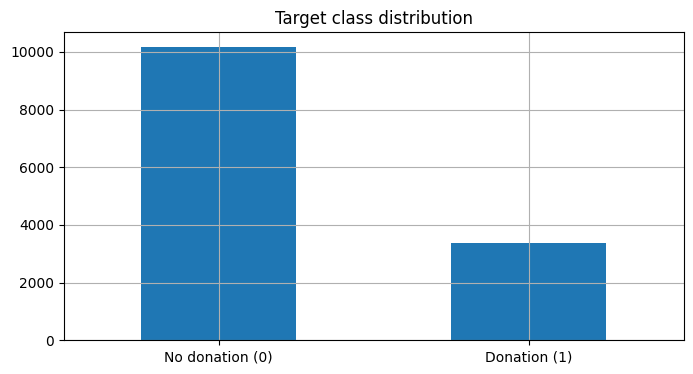

Positive response rate: 0.25


In [0]:
# Visualize the target distribution to assess imbalance.
# This is directly relevant for metric selection and threshold tuning.
class_counts = y_full.value_counts().sort_index()
ax = class_counts.plot(kind='bar')
ax.set_xticklabels(['No donation (0)', 'Donation (1)'], rotation=0)
ax.set_title('Target class distribution')
plt.show()

print('Positive response rate:', round(y_full.mean(), 4))


#### Class imbalance
The positive class is materially less frequent than the negative class. This is one of the reasons why **accuracy** is not used as the primary optimization criterion. A classifier could achieve high accuracy by favoring the majority class, yet still perform poorly on donor detection.

---

In [0]:
# Compute simple linear correlations between numerical predictors and the target.
# This is not used as a formal feature-selection rule; it is an exploratory signal.
eda_df = pd.concat([X_model_full[numeric_cols], y_full], axis=1)
correlations = (
    eda_df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)
correlations.head(12)


FREQUENCY_STATUS_97NK          0.134292
RECENT_CARD_RESPONSE_COUNT     0.129272
RECENT_RESPONSE_COUNT          0.127283
RECENT_RESPONSE_PROP           0.115839
PEP_STAR                       0.103796
FILE_CARD_GIFT                 0.102140
RECENT_CARD_RESPONSE_PROP      0.100305
LIFETIME_GIFT_COUNT            0.100235
MONTHS_SINCE_LAST_GIFT        -0.092431
RECENT_AVG_GIFT_AMT           -0.080769
MONTHS_SINCE_LAST_PROM_RESP   -0.070623
LAST_GIFT_AMT                 -0.068687
Name: TARGET_B, dtype: float64

#### Behavior-related variables are likely important
Variables related to historical donation frequency, donation amount, or recency tend to show stronger associations with the target. This is intuitively coherent: people with stronger prior engagement are more likely to donate again. Although correlation does not imply causality, these patterns justify giving special attention to behavioral variables in later interpretation.

---

## 7. Preprocessing design

This section defines the preprocessing strategy applied before training the models. The goal is to make sure that numerical and categorical variables are treated in a consistent, reproducible way, and in a way that is suitable for each type of algorithm.

The code creates different preprocessing pipelines to support the needs of linear models, tree-based models, and models that require dense matrices, such as Gaussian Naive Bayes.

---

### Why use pipelines instead of manual preprocessing?

Pipelines are important because they organize all transformations into one controlled workflow. This helps ensure that each transformation, such as imputation, standardization, or one-hot encoding, is learned only from the data used to train each model.

This approach reduces the risk of information leakage, improves reproducibility, and makes it easier to apply the same transformations to the validation set, internal test set, and external test set.

In this project, pipelines also make it possible to create different versions of preprocessing for different model families.

---

### Summary of the applied logic

The preprocessing strategy follows these principles:

1. Treat missing numerical values with median imputation.
2. Treat missing categorical values with imputation using the most frequent category.
3. Apply standardization only when the model is sensitive to scale.
4. Avoid unnecessary standardization for tree-based models.
5. Transform categorical variables using one-hot encoding.
6. Use `handle_unknown='ignore'` to protect the pipeline against new categories.
7. Create dense preprocessing versions for models that do not accept sparse matrices.
8. Use `ColumnTransformer` to correctly apply different transformations to numerical and categorical columns.

This architecture makes the modeling workflow more robust, modular, and aligned with the specific needs of each model family.

---

### Numerical preprocessing choices

#### Median imputation

```python id="hlqu7e"
numeric_pipe_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_pipe_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])
```

Median imputation is used for all numerical variables. When a numerical column has missing values, those values are replaced by the median of that column.

This choice is appropriate because the median is more robust to skewness and extreme values than the mean. In variables related to donations, amounts, frequency, or financial behavior, skewed distributions are common. A small number of very high values can strongly affect the mean.

Therefore, the median provides a simple and stable way to fill missing values without being strongly influenced by outliers.

---

### Standardization for scale-sensitive models

The `numeric_pipe_scaled` pipeline includes two steps:

1. median imputation;
2. standardization with `StandardScaler`.

Standardization transforms numerical variables into a comparable scale, usually with a mean close to 0 and a standard deviation close to 1.

This step is important for scale-sensitive models, such as Logistic Regression. In linear models, variables with larger scales can have too much influence on the optimization process only because of their numerical size.

For this reason, the scaled preprocessor is used for linear models:

```python id="h2h9q0"
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', numeric_pipe_scaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])
```

In this case:

* numerical columns receive median imputation and standardization;
* categorical columns receive mode imputation and one-hot encoding.

---

### Numerical preprocessing without standardization for tree-based models

The `numeric_pipe_unscaled` pipeline only applies median imputation:

```python id="884brz"
numeric_pipe_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])
```

This pipeline is used for tree-based models, such as Decision Trees, Random Forest, Gradient Boosting, XGBoost, LightGBM, or similar models.

Tree-based models do not depend on the absolute scale of variables in the same way as linear models. They make splits based on feature thresholds, so standardization usually does not improve performance and may be unnecessary.

For this reason, the code creates a specific preprocessor for tree-based models:

```python id="iatxtj"
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_pipe_unscaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])
```

In this case:

* numerical columns receive only median imputation;
* categorical columns receive the same treatment used for the other models.

This separation makes the pipeline more efficient and avoids transformations that do not add value for this type of algorithm.

---

### Categorical preprocessing choices

#### Imputation with the most frequent category

```python id="d91m0y"
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
```

For categorical variables, missing values are filled with the most frequent category, also called the mode.

This approach is simple, stable, and easy to interpret. It allows all observations to remain in the dataset without creating complex artificial values or removing rows with missing data.

Imputation with the most frequent category is especially useful when the main goal is prediction, not causal inference.


---

#### One-hot encoding with `handle_unknown='ignore'`

After imputation, categorical variables are transformed using one-hot encoding.

One-hot encoding converts categories into binary columns, allowing models to use categorical information in numerical format.

The option `handle_unknown='ignore'` is important because it protects the pipeline against new categories that may appear in the validation set, internal test set, or external test set, but were not present in the training data.

Without this option, the model could fail when it finds an unknown category. With `handle_unknown='ignore'`, the encoder simply ignores the new category and the pipeline continues to work.

This choice is important in real-world scenarios, where new categories can naturally appear over time.

In [0]:
# ******************************************************************************************************************************
# Numerical preprocessing for scale-sensitive models like Logistic Regression
# Median imputation is robust to skewed donation-related distributions,
# and standardization improves optimization for linear classifiers.
numeric_pipe_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # When a numeric column has NaN, the missing value is replaced by the column's median.
    ('scaler', StandardScaler()) # transforms the numerical variables to make them comparable on a scale.
])

# Numerical preprocessing for tree-based models.
# Trees are not sensitive to feature scale, so standardization is unnecessary.
numeric_pipe_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [0]:
# ******************************************************************************************************************************
# Categorical preprocessing shared by all models.
# The most frequent category is used as a simple baseline imputer,
# and one-hot encoding turns discrete labels into model-usable indicators.
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fulfill with mode.
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Flag handle_unknow = ignore in case a new category appears in the test set that wasn't seen in the training, the encoder doesn't fail. It simply ignores that category. Because new categories can emerge in real data, and the pipeline needs to continue functioning.
])

# Full preprocessor for linear models.
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', numeric_pipe_scaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# Full preprocessor for tree-based models.
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_pipe_unscaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

---

### Use of `ColumnTransformer`

The code uses `ColumnTransformer` to apply different transformations to different groups of columns:

```python id="7c0x4n"
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', numeric_pipe_scaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_pipe_unscaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])
```

This allows:

* numerical variables to be processed with numerical pipelines;
* categorical variables to be processed with categorical pipelines;
* all transformations to be combined into one final matrix ready for the model.

This approach is safer and more organized than transforming each group of columns manually.

In [0]:
# ******************************************************************************************************************************
# GaussianNB does not work directly with sparse matrices produced by OneHotEncoder.
# For that reason, a dense categorical preprocessor is recommended if categorical features are included.
# If your existing categorical pipeline uses OneHotEncoder, set sparse_output=False (or sparse=False in older versions).
categorical_pipe_dense = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_scaled_dense = ColumnTransformer(transformers=[
    ('num', numeric_pipe_scaled, numeric_cols),
    ('cat', categorical_pipe_dense, categorical_cols)
])

preprocessor_tree_dense = ColumnTransformer(transformers=[
    ('num', numeric_pipe_unscaled, numeric_cols),
    ('cat', categorical_pipe_dense, categorical_cols)
])


### Why keep different preprocessors?

The code keeps four main preprocessing versions:

| Preprocessor                | Numerical scaling |  One-hot encoding | Expected use                                               |
| --------------------------- | ----------------: | ----------------: | ---------------------------------------------------------- |
| `preprocessor_scaled`       |               Yes | Sparse by default | Linear models, such as Logistic Regression                 |
| `preprocessor_tree`         |                No | Sparse by default | Tree-based models                                          |
| `preprocessor_scaled_dense` |               Yes |             Dense | Models that need scaling and a dense matrix                |
| `preprocessor_tree_dense`   |                No |             Dense | Models that do not need scaling but require a dense matrix |

This separation is methodologically correct because different algorithms have different requirements.

Linear models usually benefit from standardized numerical variables. Tree-based models do not need this transformation. Some probabilistic models, such as Gaussian Naive Bayes, may require dense input.

Therefore, the preprocessing design keeps flexibility without compromising the consistency of the pipeline.

---

#### Preprocessors for models that require dense matrices

The code also creates dense versions of the preprocessors:

```python id="b126vn"
categorical_pipe_dense = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
```

By default, `OneHotEncoder` may produce a sparse matrix. A sparse matrix is efficient when there are many binary columns with many zeros, which is common after one-hot encoding.

However, some models do not directly accept sparse matrices. Gaussian Naive Bayes, for example, usually expects a dense matrix as input.

For this reason, the code creates an alternative categorical pipeline with:

```python id="382mpb"
sparse_output=False
```

This option forces `OneHotEncoder` to return a dense matrix.

---

#### Dense preprocessor with standardization

```python id="r38ztn"
preprocessor_scaled_dense = ColumnTransformer(transformers=[
    ('num', numeric_pipe_scaled, numeric_cols),
    ('cat', categorical_pipe_dense, categorical_cols)
])
```

This preprocessor combines:

* median imputation for numerical variables;
* standardization of numerical variables;
* imputation with the most frequent category for categorical variables;
* one-hot encoding in dense format.

It is suitable for models that need scaled features and also do not work well with sparse matrices.

---

#### Dense preprocessor without standardization

```python id="h3ebqj"
preprocessor_tree_dense = ColumnTransformer(transformers=[
    ('num', numeric_pipe_unscaled, numeric_cols),
    ('cat', categorical_pipe_dense, categorical_cols)
])
```

This preprocessor combines:

* median imputation for numerical variables;
* no standardization;
* imputation with the most frequent category for categorical variables;
* one-hot encoding in dense format.

It can be used when the model does not need scaled numerical variables, but requires or benefits from a dense matrix.

## 8. Initial benchmark on the training partition

The purpose of this section is to compare several candidate algorithms under a common assessment protocol before moving to manual tuning.

### Why benchmark first?

A benchmark phase helps answer a fundamental question: which model families appear promising enough to justify deeper optimization? Rather than tuning everything exhaustively, we first screen a diverse set of candidate methods.

### Candidate models

The notebook evaluates seven scikit-learn classifiers that represent complementary modeling families while remaining fully aligned with the project restriction to vanilla scikit-learn:

1. **Logistic Regression** — a strong and interpretable linear baseline, often competitive in high-dimensional settings created by one-hot encoding.
2. **Decision Tree (ID3-like / Entropy)** — a single-tree classifier using entropy as the split criterion, included as the closest scikit-learn approximation to an ID3-style tree.
3. **Decision Tree (Divisive / Gini)** — a top-down divisive classification tree using the Gini criterion, included to contrast an alternative tree-growing strategy with the entropy-based version.
4. **Random Forest** — an ensemble of decision trees that generally improves robustness and predictive stability relative to a single tree.
5. **Neural Network** — a multi-layer perceptron classifier that can capture more flexible non-linear relationships once numeric variables are properly scaled.
6. **Gaussian Naive Bayes** — a probabilistic classifier based on Bayes' theorem with conditional independence assumptions, included as a simple and computationally efficient probabilistic baseline.
7. **K-Nearest Neighbors (KNN)** — an instance-based classifier that predicts each case from its nearest neighbors in feature space, included as a distance-based non-linear benchmark. Two search backends are tested, **Ball Tree** and **KD Tree**, to remain consistent with the algorithms discussed in class while keeping the model itself within standard scikit-learn.

### Assessment protocol

The benchmark is run with **stratified 5-fold cross-validation on the training partition only**.

This is a deliberate design choice:

- using only the training partition preserves the independence of the validation and internal test sets;
- cross-validation provides a more stable estimate than relying on a single split;
- stratification helps preserve the class distribution across folds, which is especially important in imbalanced classification problems.

### Metrics reported

The benchmark reports multiple metrics to avoid making decisions from a single perspective, while still treating **F1-score as the main selection criterion** because it is most closely aligned with the project objective.

- **F1-score**: primary metric, suitable for imbalanced classification and aligned with the competition objective.
- **Precision**: relevant because false positives may lead to unnecessary donor targeting.
- **Recall**: relevant because failing to identify likely donors also carries an operational cost.
- **ROC AUC**: useful as a threshold-independent measure of ranking quality.

The benchmark is not used as the final model-selection stage by itself. Instead, it acts as a screening step that identifies the most promising candidates for deeper tuning and final comparison.



In [0]:
# Define the cross-validation strategy for the initial benchmark.
# Only the training partition is used here, preserving validation and internal test.
# Without stratification, some folds could become artificially unbalanced.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['f1', 'precision', 'recall', 'roc_auc']

In [0]:

benchmark_models = {

    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=25,
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=10,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]),

    'Neural Network': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ]),

    'Gaussian Naive Bayes': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled_dense),
        ('model', GaussianNB())
    ]),

    'KNN (Ball Tree)': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', KNeighborsClassifier(
            n_neighbors=15,
            weights='distance',
            metric='minkowski',
            p=2,                  # Euclidean distance
            algorithm='ball_tree'
        ))
    ]),

    'KNN (KD Tree)': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', KNeighborsClassifier(
            n_neighbors=15,
            weights='distance',
            metric='minkowski',
            p=2,                  # Euclidean distance
            algorithm='kd_tree'
        ))
    ])
}

In [0]:
# Evaluate each candidate with the same protocol and summarize the mean test-fold metrics.
benchmark_rows = []
for name, pipeline in benchmark_models.items():
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )
    benchmark_rows.append({
        'model': name,
        'f1_mean': cv_results['test_f1'].mean(),
        'precision_mean': cv_results['test_precision'].mean(),
        'recall_mean': cv_results['test_recall'].mean(),
        'roc_auc_mean': cv_results['test_roc_auc'].mean()
    })

benchmark_df = pd.DataFrame(benchmark_rows).sort_values('f1_mean', ascending=False)
benchmark_df


,model,f1_mean,precision_mean,recall_mean,roc_auc_mean
0,Logistic Regression,0.406028,0.316208,0.567352,0.609191
2,Random Forest,0.377154,0.340386,0.423785,0.612813
4,Gaussian Naive Bayes,0.355070,0.335921,0.379522,0.596995
1,Decision Tree,0.100238,0.367966,0.059014,0.571845
5,KNN (Ball Tree),0.093702,0.383023,0.053584,0.558852
6,KNN (KD Tree),0.093702,0.383023,0.053584,0.558852
3,Neural Network,0.049100,0.468742,0.026540,0.606100


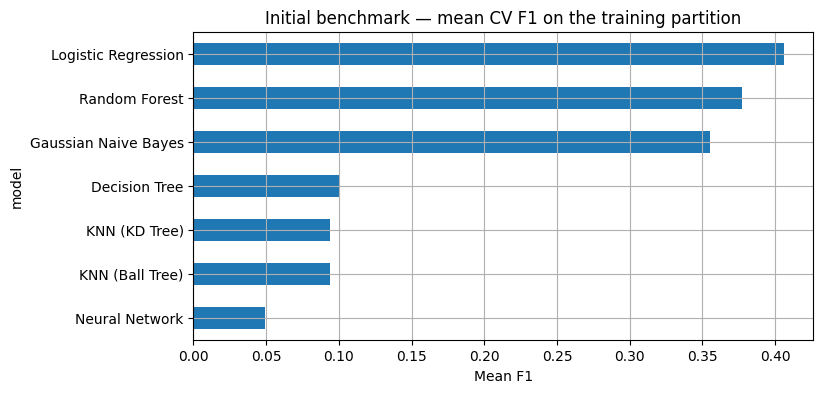

In [0]:
# Plot the benchmark results for an easier visual comparison of candidate models.
plot_df = benchmark_df.sort_values('f1_mean', ascending=True)
ax = plot_df.plot(x='model', y='f1_mean', kind='barh', legend=False)
ax.set_title('Initial benchmark — mean CV F1 on the training partition')
ax.set_xlabel('Mean F1')
plt.show()


### Why these candidates were selected for tuning

The benchmark stage provides an initial ranking, but the final choice for tuning should not rely only on average cross-validation scores. Instead, the benchmark is used as a **screening step** to identify the most competitive candidates for more detailed evaluation.

Based on the benchmark results, the **three best-performing models** were carried forward:

- **Logistic Regression**, because it achieved the **highest F1-score** and the **highest recall**, making it the strongest overall model under the project’s main evaluation criterion.
- **Random Forest**, because it obtained the **second-best F1-score** and the **highest ROC AUC**, making it the strongest non-linear ensemble in the benchmark.
- **Gaussian Naive Bayes**, because it delivered the **third-best F1-score** and offered a simple probabilistic alternative to the other two model families.

This selection is useful methodologically because it preserves both performance and diversity:

- **Logistic Regression** represents a linear and interpretable baseline;
- **Random Forest** represents a flexible non-linear ensemble capable of modeling interactions and heterogeneous predictor effects;
- **Gaussian Naive Bayes** represents a probabilistic classifier based on conditional independence assumptions, offering a conceptually different view of the classification problem.

The remaining benchmarked models were not retained because their results were substantially weaker:

- **Decision Tree** showed very low recall and F1-score, indicating that a single tree was not sufficient for the complexity of the problem.
- **KNN (Ball Tree and KD Tree)** produced nearly identical but weak results, suggesting that the instance-based approach was not competitive in this feature space.
- **Neural Network** achieved the lowest F1-score and recall, indicating that, under the tested configuration, its flexibility did not translate into effective predictive performance.

Overall, the three selected models were retained because they combined the best benchmark results with meaningful methodological contrast, making the tuning stage more informative and academically stronger than focusing on only one modeling family.



---

## 9. Hyperparameter tuning on the validation partition

This section refines the three benchmark-selected candidates using a two-step tuning strategy: a **manual tuning stage** followed by a **GridSearch-based confirmation stage**.

The goal is not to duplicate work unnecessarily, but to combine **explainability** with **methodological verification**.

### Why start with manual tuning?

The manual tuning stage was implemented first because it is easier to explain each tested configuration once it is is explicitly visible, which helps justify why certain values were explored and how the final candidates emerged.

### Why run GridSearch afterwards?

Once the manual tuning stage identified promising hyperparameter regions, `GridSearchCV` was used as a systematic verification step.

The purpose of this second stage was not to replace the manual search, but to check whether the manually chosen configurations were already well calibrated. In other words, GridSearch was used to answer the following question:

> *Did the manual tuning miss any stronger configuration inside the tested search space?*

In this project, the answer was effectively **no**. For all three selected models, the best manual configuration matched the best GridSearch result exactly, including the final threshold-selected validation performance. This strengthens the credibility of the manual tuning decisions and shows that the initial search spaces were well chosen.

### Why tune the classification threshold?

All three selected models produce class probabilities. However, the default classification threshold of **0.50** is not guaranteed to be optimal, especially in an imbalanced classification problem where **F1-score** is the main performance criterion.

For that reason, threshold tuning was treated as a separate and explicit step after hyperparameter selection. The logic is the following:

- first, choose the model configuration that learns the best probability estimates;
- then, choose the threshold that converts those probabilities into class labels in the way that best maximizes validation F1.

This is especially important in donation-response prediction, where the trade-off between **precision** and **recall** has practical consequences.

### What did the comparison between manual tuning and GridSearch show?

The comparison showed that the manual tuning choices were **fully validated** by GridSearch:

- **Logistic Regression** selected `C = 1` in both approaches, with the same best threshold (`0.42`) and identical validation metrics.
- **Random Forest** selected the same best configuration in both approaches, again with the same best threshold (`0.44`) and identical validation metrics.
- **Gaussian Naive Bayes** also converged to the same `var_smoothing` value and threshold in both approaches.

This consistency is important because it shows that the manual tuning stage was not arbitrary. Instead, it was already identifying the strongest configurations later confirmed by the automated search.

### Methodological separation

At this stage:

- the model is fitted on **train**;
- hyperparameters are selected through manual tuning and then checked with **GridSearchCV**, still using only the training partition;
- probability thresholds are optimized on **validation**;
- the internal test set remains untouched.

This separation is essential to preserve the credibility of the final evaluation, because it ensures that the internal test set is only used after model design decisions have already been completed.

### Interpretation of this tuning strategy

Taken together, the two tuning stages serve different but complementary purposes:

- the **manual tuning** stage improves interpretability and makes the search process easier to justify;
- the **GridSearch** stage improves methodological reassurance by confirming that the manual choices were not missing better alternatives within the explored space.

Therefore, the apparent redundancy is actually intentional and useful: the notebook first shows *how* the tuning decisions were made, and then demonstrates that those decisions were *empirically validated* by an automated search procedure.

### Probability thresholds models

In [0]:
# Evaluate a grid of probability thresholds.
# This remains useful because even after hyperparameter tuning, the default 0.50
# threshold may still be suboptimal for F1 in an imbalanced classification task.
def evaluate_thresholds(y_true, proba, grid=None):
    if grid is None:
        grid = np.round(np.arange(0.20, 0.81, 0.02), 2)

    rows = []
    for thr in grid:
        pred = (proba >= thr).astype(int)
        rows.append({
            'threshold': thr,
            'f1': f1_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0)
        })

    return (
        pd.DataFrame(rows)
        .sort_values(['f1', 'precision', 'recall'], ascending=False)
        .reset_index(drop=True)
    )

In [0]:
# Fit a model on the training partition, score its probabilities on validation,
# and select the threshold that maximizes the validation F1 score.
def fit_score_threshold(model, X_train, y_train, X_valid, y_valid):
    model.fit(X_train, y_train)
    valid_proba = model.predict_proba(X_valid)[:, 1] # probability of a positive event.
    threshold_df = evaluate_thresholds(y_valid, valid_proba)
    best_thr = float(threshold_df.iloc[0]['threshold'])
    return model, threshold_df, best_thr

 The threshold functions separate probability estimation from final class assignment. First, the model is trained normally and produces validation-set probabilities for the positive class. Then, instead of accepting the default 0.50 cutoff, a grid of candidate thresholds is evaluated. For each threshold, probabilities are converted into class predictions and scored using F1, precision, and recall. The threshold that maximizes validation F1 is selected as the operating decision rule for that model.

---

## Manual Tunnings

### 1) Logist Regression

In [0]:
# ------------------------------------------------------------
# 1) Logistic Regression tuning
# ------------------------------------------------------------
# Transparent tuning loop for Logistic Regression.
# We vary the inverse regularization strength C and keep the search space intentionally
# compact so every tested configuration can be explained during the presentation.
lr_candidates = [0.05, 0.1, 0.3, 1, 3]

lr_results = []
lr_artifacts = {}

for C in lr_candidates:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            C=C
        ))
    ])

    fitted_model, threshold_df, best_thr = fit_score_threshold(
        model, X_train, y_train, X_valid, y_valid
    )
    best_row = threshold_df.iloc[0].to_dict()

    lr_results.append({
        'C': C,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall']
    })

    lr_artifacts[C] = (fitted_model, threshold_df, best_thr)

lr_tuning_df = pd.DataFrame(lr_results).sort_values('val_f1', ascending=False).reset_index(drop=True)
lr_tuning_df


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run fearless-owl-45 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/2525c7a5202d4b27b822d440fb07116a
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run stylish-moth-838 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/d1cd00e02ee943b2aa33adb8b3a16511
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run gregarious-skunk-161 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/01aabc1f64a548c2bc7032b09611521d
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


,C,best_threshold,val_f1,val_precision,val_recall
0,1.00,0.42,0.414803,0.280793,0.793510
1,0.05,0.42,0.413873,0.280125,0.792035
2,0.10,0.42,0.413713,0.279979,0.792035
3,3.00,0.42,0.412809,0.279519,0.789086
4,0.30,0.42,0.412355,0.279289,0.787611


### 2) Randown Forest

In [0]:
# ------------------------------------------------------------
# 2) Random Forest tuning
# ------------------------------------------------------------
# Transparent tuning loop for Random Forest.
# The search space explores different trade-offs between ensemble size, depth,
# and leaf granularity, all of which affect bias-variance behavior.
rf_candidates = [
    {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 10},
    {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 10},
    {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 5},
    {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 5},
]

rf_results = []
rf_artifacts = {}

for cfg in rf_candidates:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced_subsample',
            **cfg
        ))
    ])

    fitted_model, threshold_df, best_thr = fit_score_threshold(
        model, X_train, y_train, X_valid, y_valid
    )
    best_row = threshold_df.iloc[0].to_dict()
    label = str(cfg)

    rf_results.append({
        'config': label,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall']
    })

    rf_artifacts[label] = (fitted_model, threshold_df, best_thr)

rf_tuning_df = pd.DataFrame(rf_results).sort_values('val_f1', ascending=False).reset_index(drop=True)
rf_tuning_df



Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run incongruous-ape-209 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/2feadef9af8b442ea37b71dc367e9d30
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run brawny-eel-381 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/27e91b776a7e4b65a35078847d503996
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run amusing-crow-823 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/cdb41c41b08c4b598d154ea0e14e8cf1
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


,config,best_threshold,val_f1,val_precision,val_recall
0,"{'n_estimators': 200, 'max_depth': 6, 'min_sam...",0.44,0.417910,0.293941,0.722714
1,"{'n_estimators': 300, 'max_depth': 8, 'min_sam...",0.42,0.417872,0.293660,0.724189
2,"{'n_estimators': 300, 'max_depth': 12, 'min_sa...",0.36,0.415428,0.285478,0.762537
3,"{'n_estimators': 200, 'max_depth': 8, 'min_sam...",0.42,0.415237,0.289889,0.731563


### 3) Gaussian Naive Bayes

In [0]:
# ------------------------------------------------------------
# 3) Gaussian Naive Bayes tuning
# ------------------------------------------------------------
# Gaussian Naive Bayes has a smaller hyperparameter space in scikit-learn.
# We tune var_smoothing, which stabilizes variance estimates and can matter when
# numeric predictors have different dispersion patterns after preprocessing.
gnb_candidates = [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
"""
1e-12 = 0.000000000001
1e-11 = 0.00000000001
1e-10 = 0.0000000001
1e-9 = 0.000000001
1e-8 = 0.00000001
"""
gnb_results = []
gnb_artifacts = {}

for var_smoothing in gnb_candidates:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor_scaled_dense),
        ('model', GaussianNB(var_smoothing=var_smoothing))
    ])

    fitted_model, threshold_df, best_thr = fit_score_threshold(
        model, X_train, y_train, X_valid, y_valid
    )
    best_row = threshold_df.iloc[0].to_dict()

    gnb_results.append({
        'var_smoothing': var_smoothing,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall']
    })

    gnb_artifacts[var_smoothing] = (fitted_model, threshold_df, best_thr)

gnb_tuning_df = pd.DataFrame(gnb_results).sort_values('val_f1', ascending=False).reset_index(drop=True)
gnb_tuning_df

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run whimsical-auk-458 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/cce04405b848412aabd9645c9d474c7e
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run silent-bee-127 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/3f14090bd8e946e6921258d6231007e3
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run luminous-auk-386 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/81a041a2e4b147e281d10e3d28536d13
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


,var_smoothing,best_threshold,val_f1,val_precision,val_recall
0,1.000000e-12,0.2,0.397237,0.325779,0.50885
1,1.000000e-11,0.2,0.397237,0.325779,0.50885
2,1.000000e-10,0.2,0.397237,0.325779,0.50885
3,1.000000e-09,0.2,0.397237,0.325779,0.50885
4,1.000000e-08,0.2,0.397237,0.325779,0.50885


### Manual Tunning comparisons

In [0]:
best_lr = lr_tuning_df.iloc[0].copy()
best_rf = rf_tuning_df.iloc[0].copy()
best_gnb = gnb_tuning_df.iloc[0].copy()

tuning_summary = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'best_config': f"C={best_lr['C']}",
        'best_threshold': best_lr['best_threshold'],
        'val_f1': best_lr['val_f1'],
        'val_precision': best_lr['val_precision'],
        'val_recall': best_lr['val_recall']
    },
    {
        'model': 'Random Forest',
        'best_config': best_rf['config'],
        'best_threshold': best_rf['best_threshold'],
        'val_f1': best_rf['val_f1'],
        'val_precision': best_rf['val_precision'],
        'val_recall': best_rf['val_recall']
    },
    {
        'model': 'Gaussian Naive Bayes',
        'best_config': f"var_smoothing={best_gnb['var_smoothing']}",
        'best_threshold': best_gnb['best_threshold'],
        'val_f1': best_gnb['val_f1'],
        'val_precision': best_gnb['val_precision'],
        'val_recall': best_gnb['val_recall']
    }
]).sort_values('val_f1', ascending=False).reset_index(drop=True)

tuning_summary

,model,best_config,best_threshold,val_f1,val_precision,val_recall
0,Random Forest,"{'n_estimators': 200, 'max_depth': 6, 'min_sam...",0.44,0.417910,0.293941,0.722714
1,Logistic Regression,C=1.0,0.42,0.414803,0.280793,0.793510
2,Gaussian Naive Bayes,var_smoothing=1e-12,0.20,0.397237,0.325779,0.508850


## Grid Search Tunnings

### Grid Search Settings

In [0]:
# Fit a GridSearchCV object on the training partition only, then score the best
# estimator on validation probabilities and choose the threshold that maximizes F1.
def fit_gridsearch_and_threshold(
    pipeline,
    param_grid,
    X_train,
    y_train,
    X_valid,
    y_valid,
    cv=5,
    scoring='f1',
    n_jobs=1
):
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        refit=True,
        verbose=0
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    valid_proba = best_model.predict_proba(X_valid)[:, 1]
    threshold_df = evaluate_thresholds(y_valid, valid_proba)
    best_thr = float(threshold_df.iloc[0]['threshold'])

    return grid, best_model, threshold_df, best_thr

### 1) Logistic Regression

In [0]:
# ------------------------------------------------------------
# 1) Logistic Regression - GridSearchCV + threshold tuning
# ------------------------------------------------------------
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

lr_param_grid = {
    'model__C': [0.05, 0.1, 0.3, 1, 3],
    'model__solver': ['lbfgs']
}

lr_grid, lr_best_model, lr_threshold_df, lr_best_thr = fit_gridsearch_and_threshold(
    pipeline=lr_pipeline,
    param_grid=lr_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    cv=5,
    scoring='f1',
    n_jobs=1
)

lr_best_row = lr_threshold_df.iloc[0].to_dict()

lr_grid_results = pd.DataFrame(lr_grid.cv_results_)[[
    'param_model__C',
    'param_model__solver',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).reset_index(drop=True)

print("Best LR params:", lr_grid.best_params_)
print("Best LR CV F1:", lr_grid.best_score_)
print("Best LR validation threshold:", lr_best_thr)

lr_grid_results.head(10)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run invincible-hog-120 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/1e6a2b4a3ea14ab9ae81a3d81004ffac
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run hilarious-foal-435 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/2d397506daf54b4783952ee0d4d3e9da
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run gentle-boar-311 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/8c4191e3c0db4c22a99d03b8c8a964f7
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run unleashed-fawn-389 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/927ab9b8ad06486695e49f83ea8e26d6
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/212710666147

,param_model__C,param_model__solver,mean_test_score,std_test_score,rank_test_score
0,1,lbfgs,0.402939,0.012616,1
1,3,lbfgs,0.402863,0.012953,2
2,0.05,lbfgs,0.402683,0.015316,3
3,0.3,lbfgs,0.402521,0.012860,4
4,0.1,lbfgs,0.401960,0.013803,5


### 2) Random Forest

In [0]:
# ------------------------------------------------------------
# 2) Random Forest - GridSearchCV + threshold tuning
# ------------------------------------------------------------
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        n_jobs=1
    ))
])

rf_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [6, 8, 12],
    'model__min_samples_leaf': [5, 10]
}

rf_grid, rf_best_model, rf_threshold_df, rf_best_thr = fit_gridsearch_and_threshold(
    pipeline=rf_pipeline,
    param_grid=rf_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    cv=5,
    scoring='f1',
    n_jobs=1
)

rf_best_row = rf_threshold_df.iloc[0].to_dict()

rf_grid_results = pd.DataFrame(rf_grid.cv_results_)[[
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__min_samples_leaf',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).reset_index(drop=True)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_)
print("Best RF validation threshold:", rf_best_thr)

rf_grid_results.head(10)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run gaudy-cow-458 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/75d5b66494cf410389e2d723a797d3bc
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run youthful-hog-19 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/1d0d567efafe4d2b96d71cb1a77a537d
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run zealous-smelt-112 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/315a92e1a9f4425fbf5e9f1baa06c550
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run adaptable-boar-351 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/3fdfc2ba22ec4600a6491ebb55b722d5
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,200,6,10,0.394695,0.010952,1
1,300,6,10,0.394286,0.010998,2
2,300,6,5,0.393813,0.009363,3
3,200,6,5,0.391787,0.006289,4
4,200,8,10,0.384497,0.006513,5
5,300,8,10,0.381834,0.004487,6
6,200,8,5,0.377913,0.006943,7
7,300,8,5,0.374898,0.009248,8
8,200,12,10,0.342166,0.011942,9
9,300,12,10,0.340616,0.008978,10


### 3) Gaussian Naive Bayes

In [0]:
# ------------------------------------------------------------
# 3) Gaussian Naive Bayes - GridSearchCV + threshold tuning
# ------------------------------------------------------------
gnb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled_dense),
    ('model', GaussianNB())
])

gnb_param_grid = {
    'model__var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
}

gnb_grid, gnb_best_model, gnb_threshold_df, gnb_best_thr = fit_gridsearch_and_threshold(
    pipeline=gnb_pipeline,
    param_grid=gnb_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    cv=5,
    scoring='f1',
    n_jobs=1
)

gnb_best_row = gnb_threshold_df.iloc[0].to_dict()

gnb_grid_results = pd.DataFrame(gnb_grid.cv_results_)[[
    'param_model__var_smoothing',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).reset_index(drop=True)

print("Best GNB params:", gnb_grid.best_params_)
print("Best GNB CV F1:", gnb_grid.best_score_)
print("Best GNB validation threshold:", gnb_best_thr)

gnb_grid_results.head(10)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run rogue-ray-714 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/4b754f989c38423b9941bc2f01798d49
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run enchanting-bug-857 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/560918648b6d4956a1253d1d71278639
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run carefree-horse-506 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/25b168ea6e744d71a7db4b0d5ff0cc92
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
🏃 View run dazzling-boar-224 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/8810dfe9327c4021b9b837a5565ad658
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/212710666147837

,param_model__var_smoothing,mean_test_score,std_test_score,rank_test_score
0,0.0,0.357703,0.02868,1
1,0.0,0.357703,0.02868,1
2,0.0,0.357703,0.02868,1
3,0.0,0.357703,0.02868,1
4,0.0,0.357703,0.02868,1


## Manual and Grid Search Comparions

In [0]:
# Best rows from manual tuning tables
lr_manual_best = lr_tuning_df.iloc[0]
rf_manual_best = rf_tuning_df.iloc[0]
gnb_manual_best = gnb_tuning_df.iloc[0]

# Best rows from GridSearch threshold evaluation
lr_grid_best_row = lr_threshold_df.iloc[0]
rf_grid_best_row = rf_threshold_df.iloc[0]
gnb_grid_best_row = gnb_threshold_df.iloc[0]

manual_vs_grid = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'manual_best': f"C={lr_manual_best['C']}",
        'manual_threshold': lr_manual_best['best_threshold'],
        'manual_val_f1': lr_manual_best['val_f1'],
        'manual_val_precision': lr_manual_best['val_precision'],
        'manual_val_recall': lr_manual_best['val_recall'],
        'grid_best': str(lr_grid.best_params_),
        'grid_threshold': lr_best_thr,
        'grid_val_f1': lr_grid_best_row['f1'],
        'grid_val_precision': lr_grid_best_row['precision'],
        'grid_val_recall': lr_grid_best_row['recall']
    },
    {
        'model': 'Random Forest',
        'manual_best': rf_manual_best['config'],
        'manual_threshold': rf_manual_best['best_threshold'],
        'manual_val_f1': rf_manual_best['val_f1'],
        'manual_val_precision': rf_manual_best['val_precision'],
        'manual_val_recall': rf_manual_best['val_recall'],
        'grid_best': str(rf_grid.best_params_),
        'grid_threshold': rf_best_thr,
        'grid_val_f1': rf_grid_best_row['f1'],
        'grid_val_precision': rf_grid_best_row['precision'],
        'grid_val_recall': rf_grid_best_row['recall']
    },
    {
        'model': 'Gaussian Naive Bayes',
        'manual_best': f"var_smoothing={gnb_manual_best['var_smoothing']}",
        'manual_threshold': gnb_manual_best['best_threshold'],
        'manual_val_f1': gnb_manual_best['val_f1'],
        'manual_val_precision': gnb_manual_best['val_precision'],
        'manual_val_recall': gnb_manual_best['val_recall'],
        'grid_best': str(gnb_grid.best_params_),
        'grid_threshold': gnb_best_thr,
        'grid_val_f1': gnb_grid_best_row['f1'],
        'grid_val_precision': gnb_grid_best_row['precision'],
        'grid_val_recall': gnb_grid_best_row['recall']
    }
])

manual_vs_grid

,model,manual_best,manual_threshold,manual_val_f1,manual_val_precision,manual_val_recall,grid_best,grid_threshold,grid_val_f1,grid_val_precision,grid_val_recall
0,Logistic Regression,C=1.0,0.42,0.414803,0.280793,0.793510,"{'model__C': 1, 'model__solver': 'lbfgs'}",0.42,0.414803,0.280793,0.793510
1,Random Forest,"{'n_estimators': 200, 'max_depth': 6, 'min_sam...",0.44,0.417910,0.293941,0.722714,"{'model__max_depth': 6, 'model__min_samples_le...",0.44,0.417910,0.293941,0.722714
2,Gaussian Naive Bayes,var_smoothing=1e-12,0.20,0.397237,0.325779,0.508850,{'model__var_smoothing': 1e-12},0.20,0.397237,0.325779,0.508850


## 9. Final comparison on the internal test partition

Once the best configuration from each candidate family has been selected on validation, the notebook performs a final comparison on the internal test partition.

### Why is this step necessary?

Validation performance is useful for model development, but it is still part of the tuning process. A model that looks best on validation may not remain best on genuinely untouched data. The internal test partition provides the fairest available estimate of out-of-sample behavior within the labeled training file.

### What is compared here?

For each tuned candidate model, we evaluate:

- F1 score,
- precision,
- recall,
- ROC AUC,
- and the tuned threshold that generated the binary predictions.

### Important methodological note

This internal test partition is intended for **final comparison only**. It should not be used to tune additional hyperparameters or to search for a better threshold afterward. Otherwise, it would stop being a true test set.



In [0]:
# Retrieve the best Logistic Regression configuration according to validation F1.
best_lr_C = lr_tuning_df.iloc[0]['C']
best_lr_model, best_lr_thresholds, best_lr_thr = lr_artifacts[best_lr_C]

# Retrieve the best Random Forest configuration according to validation F1.
best_rf_label = rf_tuning_df.iloc[0]['config']
best_rf_model, best_rf_thresholds, best_rf_thr = rf_artifacts[best_rf_label]

# Compare the strongest tuned representative from each candidate family
# on the untouched internal test partition.
candidate_models = {
    'Optimized Logistic Regression': (best_lr_model, best_lr_thr),
    'Optimized Random Forest': (best_rf_model, best_rf_thr)
}

final_eval_rows = []
for name, (estimator, thr) in candidate_models.items():
    probas = estimator.predict_proba(X_test_internal)[:, 1]
    preds = (probas >= thr).astype(int)
    final_eval_rows.append({
        'model': name,
        'threshold': thr,
        'f1_test': f1_score(y_test_internal, preds),
        'precision_test': precision_score(y_test_internal, preds, zero_division=0),
        'recall_test': recall_score(y_test_internal, preds, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_internal, probas)
    })

final_eval_df = pd.DataFrame(final_eval_rows).sort_values('f1_test', ascending=False)
final_eval_df


,model,threshold,f1_test,precision_test,recall_test,roc_auc_test
1,Optimized Random Forest,0.44,0.408060,0.285211,0.716814,0.590976
0,Optimized Logistic Regression,0.42,0.407752,0.276551,0.775811,0.594943


### Final model selection rationale

The model selected for deployment is the one that performs best on the internal test partition according to the project objective, with F1 treated as the primary criterion.

### Why prioritize F1?

F1 is the harmonic mean of precision and recall. It is especially appropriate here because:

- the positive class is not dominant,
- both false positives and false negatives matter,
- and Kaggle ranking for this project is based on binary F1.

### Why not optimize exclusively for ROC AUC?

ROC AUC is useful for evaluating ranking quality, but the final competition output is a hard class prediction, not just a probability ranking. Therefore, threshold-dependent performance matters directly, and F1 is the most operationally relevant criterion for selecting the final classification rule.



In [0]:
# Freeze the winning model family and its tuned configuration.
best_model_name = final_eval_df.iloc[0]['model']
print('Chosen final model:', best_model_name)

if best_model_name == 'Optimized Logistic Regression':
    final_threshold = best_lr_thr
    final_model = Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            C=best_lr_C
        ))
    ])
else:
    # Rebuild the final Random Forest using the best validation-selected configuration.
    best_cfg = eval(best_rf_label)
    final_threshold = best_rf_thr
    final_model = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced_subsample',
            **best_cfg
        ))
    ])

print('Frozen threshold from validation:', final_threshold)


Chosen final model: Optimized Random Forest
Frozen threshold from validation: 0.44


## 10. Refit on train + validation and final internal test assessment

After selecting the winning model family and configuration, the model is retrained on the union of **train + validation**.

### Why refit after model selection?

Once the best hyperparameters and decision threshold have been fixed, it is sensible to use as much labeled data as possible for the final fitted model. By combining train and validation, we give the selected algorithm more information from which to learn the final parameter estimates.

### Why keep the threshold frozen?

The threshold was chosen on the validation set. After that decision is made, it must remain fixed. Re-optimizing the threshold using the internal test set would leak information from the evaluation data back into the model-selection process.

### Why still report internal test performance after refit?

Although the internal test set was already used for final comparison, reporting confusion matrix and classification metrics for the chosen model remains useful for interpretation. These outputs help explain where the model succeeds and where errors remain.



In [0]:
# Refit the selected model on all data that was legitimately available for model development.
X_refit = pd.concat([X_train, X_valid], axis=0)
y_refit = pd.concat([y_train, y_valid], axis=0)

final_model.fit(X_refit, y_refit)

# Evaluate the refitted model on the internal test partition using the frozen threshold.
test_proba = final_model.predict_proba(X_test_internal)[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

print('Confusion matrix:', confusion_matrix(y_test_internal, test_pred))
print('Classification report:')
print(classification_report(y_test_internal, test_pred, digits=4))
print('ROC AUC:', round(roc_auc_score(y_test_internal, test_proba), 4))
print('F1     :', round(f1_score(y_test_internal, test_pred), 4))


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run luxuriant-dove-516 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/fbf07cd61bea4d8c873989b719b1ecd6
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372
Confusion matrix: [[ 818 1216]
 [ 202  476]]
Classification report:
              precision    recall  f1-score   support

           0     0.8020    0.4022    0.5357      2034
           1     0.2813    0.7021    0.4017       678

    accuracy                         0.4771      2712
   macro avg     0.5416    0.5521    0.4687      2712
weighted avg     0.6718    0.4771    0.5022      2712

ROC AUC: 0.5872
F1     : 0.4017


## 10.1. Final results visualization — confusion matrix and F1-focused reading

Beyond printing the classification report, it is useful to visualize the confusion matrix and restate the F1, precision, and recall values in a concise table.

This makes the trade-off created by the tuned threshold easier to interpret: high recall may come at the cost of many false positives, which can still leave F1 only modestly improved.


dataset,threshold,f1,precision,recall,roc_auc
Internal test,0.44,0.4017,0.2813,0.7021,0.5872


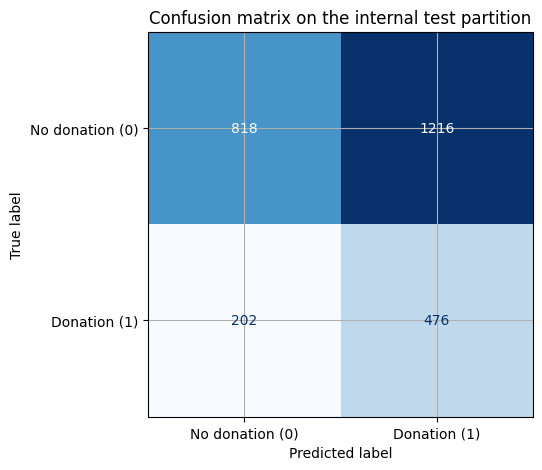

In [0]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

final_results_table = pd.DataFrame([{
    'dataset': 'Internal test',
    'threshold': final_threshold,
    'f1': f1_score(y_test_internal, test_pred),
    'precision': precision_score(y_test_internal, test_pred, zero_division=0),
    'recall': recall_score(y_test_internal, test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test_internal, test_proba)
}])
display(final_results_table.round(4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_internal,
    test_pred,
    display_labels=['No donation (0)', 'Donation (1)'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion matrix on the internal test partition')
plt.show()


## 10.2. Overfitting vs underfitting diagnostic with ROC curves

A simple way to diagnose fit behavior is to compare ROC curves and ROC AUC across the **training**, **validation**, and **internal test** partitions for the selected model family using the frozen validation threshold.

### How to read this diagnostic

- **Overfitting**: training ROC curve clearly dominates validation/test, often with a much higher AUC.
- **Underfitting**: all ROC curves stay relatively weak and close to each other, suggesting the model is not extracting enough signal even on training data.
- **Healthy generalization**: all curves are reasonably strong and similar.


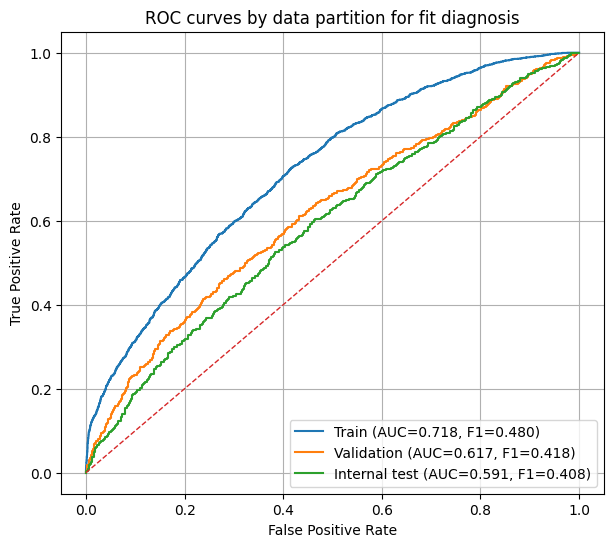

dataset,threshold,f1,precision,recall,roc_auc
Train,0.44,0.4796,0.3373,0.8294,0.7184
Validation,0.44,0.4179,0.2939,0.7227,0.6173
Internal test,0.44,0.4082,0.2854,0.7168,0.591


Diagnostic: likely overfitting — the training ROC AUC is materially higher than validation/test.


In [0]:
# Select the already trained validation-chosen model family before the refit step.
if best_model_name == 'Optimized Logistic Regression':
    selected_stage_model = best_lr_model
else:
    selected_stage_model = best_rf_model

roc_partitions = {
    'Train': (X_train, y_train),
    'Validation': (X_valid, y_valid),
    'Internal test': (X_test_internal, y_test_internal)
}

roc_rows = []
plt.figure(figsize=(7, 6))

for split_name, (X_split, y_split) in roc_partitions.items():
    split_proba = selected_stage_model.predict_proba(X_split)[:, 1]
    split_pred = (split_proba >= final_threshold).astype(int)
    split_auc = roc_auc_score(y_split, split_proba)
    split_f1 = f1_score(y_split, split_pred)

    fpr, tpr, _ = roc_curve(y_split, split_proba)
    plt.plot(fpr, tpr, label=f'{split_name} (AUC={split_auc:.3f}, F1={split_f1:.3f})')

    roc_rows.append({
        'dataset': split_name,
        'threshold': final_threshold,
        'f1': split_f1,
        'precision': precision_score(y_split, split_pred, zero_division=0),
        'recall': recall_score(y_split, split_pred, zero_division=0),
        'roc_auc': split_auc
    })

plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves by data partition for fit diagnosis')
plt.legend(loc='lower right')
plt.show()

roc_diagnostic_df = pd.DataFrame(roc_rows).round(4)
display(roc_diagnostic_df)

train_auc = roc_diagnostic_df.loc[roc_diagnostic_df['dataset'] == 'Train', 'roc_auc'].iloc[0]
valid_auc = roc_diagnostic_df.loc[roc_diagnostic_df['dataset'] == 'Validation', 'roc_auc'].iloc[0]
test_auc = roc_diagnostic_df.loc[roc_diagnostic_df['dataset'] == 'Internal test', 'roc_auc'].iloc[0]

if (train_auc - max(valid_auc, test_auc)) > 0.10:
    print('Diagnostic: likely overfitting — the training ROC AUC is materially higher than validation/test.')
elif max(train_auc, valid_auc, test_auc) < 0.65 and (train_auc - min(valid_auc, test_auc)) < 0.05:
    print('Diagnostic: likely underfitting — all ROC AUC values are low and close to each other.')
else:
    print('Diagnostic: no severe fit gap detected, but generalization remains limited and should be interpreted carefully.')


## 11. Deployment — generating predictions for the Kaggle test file

This section translates the selected modeling strategy into the final project deliverable: a CSV file with predictions for the independent `donors_test.csv` dataset.

### Why is this a distinct section?

A good notebook should clearly separate **model development** from **deployment**. Up to this point, the notebook focused on selecting a reliable solution. Here, the objective changes: we now apply the frozen solution to previously unseen cases and generate the submission artifact required by the competition.

### What is preserved from earlier stages?

- the chosen model family,
- the chosen hyperparameters,
- the validation-selected threshold,
- and the rule that `CONTROL_NUMBER` is preserved only for identification in the output file.

This section is intentionally concise because deployment should be mechanically simple once the methodology has been decided correctly.



In [0]:
# Generate final predictions for the independent Kaggle test set.
final_test_proba = final_model.predict_proba(X_kaggle_model)[:, 1]
final_test_pred = (final_test_proba >= final_threshold).astype(int)

# Preserve the control number so that each prediction remains linked to the correct donor.
submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: final_test_pred
})

submission_path = 'DM2NT_Group05_Version04_final_notebook_v7_sklearn_advanced_v2_29052026.csv'
submission.to_csv(submission_path, index=False)

print('Submission saved to:', submission_path)
submission.head()


Submission saved to: DM2NT_Group05_Version04_final_notebook_v7_sklearn_advanced_v2_29052026.csv


,CONTROL_NUMBER,TARGET_B
0,122653,0
1,184239,1
2,5172,1
3,135377,1
4,62119,0


## 12. Open-ended section

The project requires an additional analytical component that goes beyond building a predictive pipeline. In this notebook, the open-ended section focuses on **model interpretation and error analysis**.

### Why this objective is appropriate

Predictive performance alone is not enough for a convincing presentation. Stakeholders also want to know:

- which features appear most influential,
- what kinds of donors are harder to classify,
- and what the model's mistakes suggest about the limits of the available data.

### Chosen analyses

1. **Permutation importance** on the internal test partition to identify features that most affect predictive performance.
2. **Error-type analysis** to separate true positives, true negatives, false positives, and false negatives.
3. **Behavioral profile comparison** across error categories to understand where the model confuses donor types.

### Why these analyses add value

These tasks are relevant, interpretable, and defensible in a presentation. They connect the predictive pipeline to substantive donor behavior rather than stopping at a leaderboard-oriented perspective.



In [0]:
# Permutation importance is computed on the internal test partition.
# This method is model-agnostic and quantifies how much predictive performance drops
# when each variable is randomly shuffled.
perm = permutation_importance(
    final_model,
    X_test_internal,
    y_test_internal,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='f1',
    n_jobs=1
)

importance_df = pd.DataFrame({
    'feature': X_test_internal.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

importance_df.head(12)


,feature,importance_mean,importance_std
15,MEDIAN_HOME_VALUE,0.007521,0.002774
27,PER_CAPITA_INCOME,0.005644,0.001207
16,MEDIAN_HOUSEHOLD_INCOME,0.004268,0.000834
30,RECENT_AVG_GIFT_AMT,0.004217,0.003138
20,NUMBER_PROM_12,0.004208,0.001669
29,RECENT_AVG_CARD_GIFT_AMT,0.003687,0.001351
2,DONOR_AGE,0.003618,0.001281
12,LIFETIME_MAX_GIFT_AMT,0.002791,0.002897
10,LIFETIME_GIFT_AMOUNT,0.002509,0.001254
17,MONTHS_SINCE_FIRST_GIFT,0.002420,0.001934


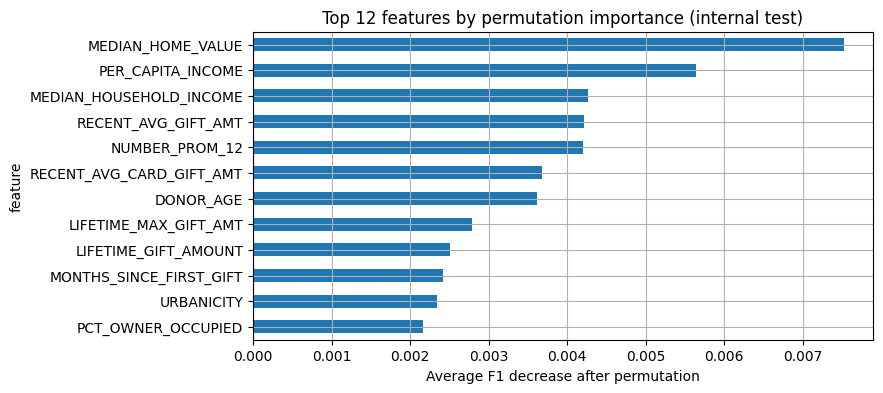

In [0]:
# Plot the most influential variables for a concise presentation-oriented summary.
plot_imp = importance_df.head(12).sort_values('importance_mean', ascending=True)
ax = plot_imp.plot(x='feature', y='importance_mean', kind='barh', legend=False)
ax.set_title('Top 12 features by permutation importance (internal test)')
ax.set_xlabel('Average F1 decrease after permutation')
plt.show()


In [0]:
# Build an error-analysis table combining predictors, probabilities, and predicted classes.
error_analysis = X_test_internal.copy()
error_analysis['y_true'] = y_test_internal.values
error_analysis['proba'] = test_proba
error_analysis['y_pred'] = test_pred

# Classify each observation by prediction outcome.
error_analysis['error_type'] = np.select(
    [
        (error_analysis['y_true'] == 1) & (error_analysis['y_pred'] == 1),
        (error_analysis['y_true'] == 0) & (error_analysis['y_pred'] == 0),
        (error_analysis['y_true'] == 0) & (error_analysis['y_pred'] == 1),
        (error_analysis['y_true'] == 1) & (error_analysis['y_pred'] == 0),
    ],
    [
        'True Positive',
        'True Negative',
        'False Positive',
        'False Negative'
    ],
    default='Other'
)

error_analysis['error_type'].value_counts()


False Positive    1216
True Negative      818
True Positive      476
False Negative     202
Name: error_type, dtype: int64

In [0]:
# Compare average behavioral variables across error types.
# This helps identify whether specific donor profiles are associated with systematic mistakes.
behavior_cols = [
    'RECENT_AVG_GIFT_AMT',
    'RECENT_RESPONSE_PROP',
    'LIFETIME_GIFT_AMOUNT',
    'MONTHS_SINCE_LAST_GIFT',
    'MONTHS_SINCE_FIRST_GIFT'
]

error_analysis.groupby('error_type')[behavior_cols].mean().round(2)


,RECENT_AVG_GIFT_AMT,RECENT_RESPONSE_PROP,LIFETIME_GIFT_AMOUNT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_FIRST_GIFT
error_type,,,,,
False Negative,19.44,0.12,91.02,19.16,58.88
False Positive,13.41,0.23,124.39,17.58,77.01
True Negative,20.11,0.13,81.56,19.64,56.89
True Positive,11.90,0.24,120.40,16.90,80.50


### Interpretation of the open-ended analysis

The interpretation layer is as important as the computation itself.

#### Feature importance
If historical giving and response variables dominate permutation importance, that is consistent with the intuition that donation behavior is persistent: donors who have engaged recently, more frequently, or with higher amounts tend to remain more likely to respond.

#### Error analysis
The confusion-matrix decomposition helps move beyond a single metric. In particular:

- **False positives** represent people predicted as donors who did not donate.
- **False negatives** represent missed opportunities, that is, people who would have donated but were not identified by the model.

Because F1 balances precision and recall, both error types matter. Examining their profiles helps explain whether the model fails mainly on borderline donors, infrequent donors, or donors with contradictory historical signals.

#### Business value of this section
This open-ended analysis strengthens the project because it connects predictive performance to substantive interpretation. It shows not only that a model was fitted, but also that the results were interrogated critically.



## 13. Final Conclusions

This notebook delivers a complete and academically defensible solution to the donor-response prediction problem, covering the full workflow from exploratory analysis and data cleaning to model training, validation, threshold optimization, and final submission generation.

More importantly, the project shows not only how to build a predictive model, but also how to evaluate whether the model is genuinely useful for the business objective. In this case, the goal was not simply to maximize accuracy, but to identify potential donors in a setting where the positive class is less frequent and where the balance between false positives and false negatives matters. For that reason, the use of **F1 Score** and the **confusion matrix** was appropriate and central to the analysis.

### Main methodological strengths

One of the main strengths of the notebook is the clear separation between **training, validation, and internal test stages**, which helps reduce leakage and keeps the evaluation process organized. The preprocessing logic was also implemented using **pipelines** and **column transformers**, ensuring that operations such as imputation, scaling, and encoding are learned only from the training data inside each fit. This is an important methodological decision because it makes the workflow more reliable and reproducible.

Another strong point is the use of a **broad benchmark of scikit-learn models**, including linear, probabilistic, distance-based, tree-based, and ensemble methods. This gives the project comparative depth and shows that the final choice was not arbitrary, but the result of structured experimentation.

The notebook also goes beyond simple model fitting by including **hyperparameter tuning** and **classification threshold optimization**. This is especially relevant in imbalanced classification problems, because the standard threshold of 0.5 is often not the best choice when the evaluation metric is F1. The final workflow also remains practical, since it ends with the creation of a **submission-ready prediction file**, which makes the modeling pipeline operational and complete.

### Main findings from the model-building process

The modeling process produced an important substantive result: the variables that appear to carry the strongest predictive signal are those related to **past donor behavior**. In practical terms, the model relies mostly on features associated with donation history, such as:

- donation recency
- previous donation amounts
- frequency of past donations
- past response behavior to campaigns

This pattern is consistent with domain intuition. Individuals who have donated more recently, more frequently, or more consistently in the past are naturally more likely to donate again. Therefore, one of the key findings of the notebook is that **historical engagement is more informative than purely demographic or weakly behavioral variables**.

A second important finding is methodological rather than substantive: although the project successfully identified a coherent set of predictors and a valid modeling workflow, the **predictive separation achieved by the final model remained modest**. The final selected model obtained a workable F1 Score, but the broader evaluation showed that the distinction between donors and non-donors was still limited.

This became especially clear when looking at the **confusion matrix**. The model was able to identify a relevant number of true donors, but it also generated a large number of **false positives**. In other words, it often predicted that a person would donate when, in fact, they would not. This means that the model captured some useful positive-class signal, but not with enough precision to be considered strongly discriminative.

A third finding is that the threshold optimization improved the decision rule for the chosen metric, but did not fully solve the model’s structural limitation. The threshold helped adjust the trade-off between precision and recall, but the broader performance metrics showed that the issue was not only the decision cutoff. The model itself had **limited ranking power**, which indicates that the available data and the chosen feature space did not allow for a much stronger class separation in the original workflow.

### Interpretation of the obtained results

From a scientific and technical perspective, the project reached a **correct and defensible first solution**, but not a highly accurate final predictive system.

The results suggest that the original pipeline was successful in:

- organizing the data properly
- avoiding obvious leakage
- comparing several modeling alternatives
- selecting a final model in a structured way

However, the same results also suggest that the original approach reached a practical ceiling. The model was not failing because of a coding issue or a wrong metric choice. Rather, it was limited by a combination of factors such as:

- restricted predictive signal in the available variables
- limited feature engineering in the original version
- difficulty in balancing recall and precision under class imbalance

This is an important conclusion because it shows maturity in the analysis: the project development does not simply claim success because a model was produced. Instead, it reveals where the model performs reasonably well and where it still struggles.

### Main limitations found in the created model

The first important limitation is that **internal performance depends on a finite split of the labeled data**. Even with a proper validation structure, the measured result is still influenced by the specific sample partition used. This means that the final internal performance should be interpreted as a strong indication, but not as a definitive estimate of real-world behavior.

The second limitation is related to the **trade-off imposed by F1 optimization**. The final threshold was adjusted to improve F1, which is appropriate for the project objective, but this also means that the final classification rule is specifically tuned for one metric. In practical terms, a threshold that is good for F1 may not be ideal if the operational goal changes, for example:

- reducing false positives
- prioritizing precision
- maximizing recall at any cost

The third limitation is visible in the confusion matrix: the model produced **many false positives**. This is a critical finding because it means the model may be too optimistic when flagging potential donors. In a campaign setting, this could lead to targeting many people who are not actually likely to respond, which reduces operational efficiency.

The fourth limitation is that the **overall discriminative ability of the model remained modest**, as indicated not only by F1 but also by the broader probability-based evaluation. In other words, even before applying the final classification threshold, the model was not ranking individuals particularly well. This suggests that threshold tuning alone cannot fully address the problem.

The fifth limitation is that the available data may not sufficiently represent all relevant aspects of donor decision-making. Important factors such as:

- campaign timing
- communication channel
- message quality
- donor motivation
- external context

are not fully captured in the modeling dataset. As a result, some donation behavior may remain inherently difficult to predict using only the variables provided.

The sixth limitation concerns the original modeling scope itself. Although the notebook benchmarked multiple classical models, the feature space remained relatively close to the raw cleaned dataset. This means that the original version extracted useful signal, but may not have fully explored interactions, ratios, response intensity measures, and other derived variables that could improve separation.

### Why the project still remains valid and strong

Despite these limitations, the notebook remains a solid project. Its strength lies not in claiming that the final model is perfect, but in showing a **complete and methodologically coherent machine learning workflow**.

The project demonstrates:

- sound preprocessing practices
- good experimental structure
- appropriate metric selection
- awareness of class imbalance
- use of threshold tuning
- transparent interpretation of model behavior

These are exactly the elements expected in a serious applied data science project. The notebook therefore succeeds not only as a coding deliverable, but also as a scientific exercise in model construction, evaluation, and critical reflection.

### Extension to the Advanced sklearn-only approach

The findings from the original workflow naturally motivated the **Advanced sklearn-only extension**.

The original results showed that the first pipeline was well built, but also revealed three clear needs:

1. a more robust validation strategy  
2. a richer way to evaluate probability quality in an imbalanced problem  
3. additional modeling steps to improve the usefulness of the predicted scores

For this reason, the advanced extension was not introduced as a replacement of the original work, but as a **direct continuation of its conclusions**.

The first improvement was the adoption of a more rigorous validation logic, such as **repeated stratified cross-validation** or nested-style validation thinking, so that hyperparameters and thresholds are chosen inside the validation process rather than being influenced by the internal test stage. This makes the evaluation more trustworthy.

The second improvement was the inclusion of **Precision-Recall Curve** and **Average Precision**, which are especially informative in imbalanced classification tasks. Since the original approach already showed tension between precision and recall, these additional metrics help explain model behavior more clearly than ROC alone.

The third improvement was the use of **finer threshold optimization**, allowing the decision cutoff to be searched more precisely. This was a logical continuation of the earlier threshold-tuning idea already present in the notebook.

The fourth improvement was **probability calibration**, introduced to make the predicted probabilities more stable and more meaningful. Since threshold quality depends heavily on probability quality, calibration is a natural extension when the original model shows limited probability separation.

The fifth improvement was the inclusion of **derived features**, such as donation ratios, response intensity variables, and missingness indicators. This directly addresses one of the original limitations: the first version relied mainly on cleaned raw features, while the extension tries to transform domain intuition into better predictive inputs.

The sixth improvement was the introduction of a stronger scikit-learn-native boosting alternative, while preserving the project’s commitment to a **vanilla scikit-learn** environment. This keeps the extension technically coherent with the project scope, while still expanding modeling capacity.

Finally, the advanced extension also includes a more explicit analysis of **class balancing strategies**, since the original confusion matrix suggested that the project needed a better understanding of how to manage the precision–recall trade-off under imbalance.

### Final statement

Overall, the original notebook provides a complete, structured, and scientifically defensible first solution to the donor-response prediction problem. Its main contribution is not only the final model itself, but also the disciplined way in which the problem was framed, cleaned, modeled, evaluated, and interpreted.

At the same time, the obtained results show that the original model still faced meaningful limitations, especially in terms of false positives, modest class separation, and dependence on a relatively restricted feature space. These findings are not weaknesses of the project presentation; they are valuable technical conclusions that justify the next stage of development.

For that reason, the **Advanced sklearn-only extension** should be understood as a coherent methodological continuation of the original notebook: it responds directly to the limitations found, strengthens the evaluation strategy, enriches the feature space, and improves the interpretability and robustness of the final predictive workflow.


# 14. Advanced sklearn-only extension

This section adds a **methodologically stronger validation track** while preserving the project in **vanilla scikit-learn**.

## What is added here

1. **Model comparison with repeated stratified CV logic** for more stable estimates.
2. **Threshold optimization on a finer grid** instead of a coarse discrete grid.
3. **Precision-Recall curve and Average Precision**, which are more informative than ROC alone under class imbalance.
4. **Probability calibration** with `CalibratedClassifierCV`.
5. **Feature engineering** based on donation intensity, recency, and ratio logic.
6. **Cleaning sensitivity analysis** to test whether deterministic contradiction-neutralization helps or hurts F1.
7. **Class-balance viability analysis** using only sklearn-compatible strategies.
8. **A native boosting option** using `HistGradientBoostingClassifier`.

> Note: XGBoost, LightGBM, and CatBoost are not part of vanilla scikit-learn. To preserve the project scope, the boosting family is represented here by **HistGradientBoostingClassifier**, which is native sklearn.



## Expected interpretation guide

When this extended section is executed, the decision logic should be:

1. Prefer the setup with the strongest **F1** among credible candidates.
2. Use **Average Precision** as the secondary ranking criterion because the dataset is imbalanced.
3. Keep an eye on the **confusion matrix** to avoid a false-positive explosion.
4. Prefer the calibrated version only if it improves decision quality, not just probability smoothness.
5. Treat class balancing as **viable but conditional**: it is useful only if the gain in recall does not destroy precision.

### Recommended practical conclusion template

- If **engineered features** improve F1/AP, they should be retained.
- If **HistGradientBoosting** beats LR/RF, it becomes the strongest vanilla-sklearn extension.
- If **relaxed cleaning** wins, revisit contradiction-neutralization rules because they may be removing signal.
- If **class balancing** mostly raises recall but worsens precision, then balancing is not attractive for this target-selection use case.


In [0]:

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import average_precision_score, precision_recall_curve, PrecisionRecallDisplay
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.utils import resample



## 14.1. Helper functions for advanced validation

The original notebook already separates fitting and threshold selection. The functions below extend that logic so the project can compare:

- coarse vs fine threshold grids,
- calibrated vs uncalibrated probabilities,
- engineered vs non-engineered features,
- and different class-balance strategies.


In [0]:

def evaluate_thresholds_fine(y_true, proba, grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.951, 0.01), 2)

    rows = []
    for thr in grid:
        pred = (proba >= thr).astype(int)
        rows.append({
            'threshold': thr,
            'f1': f1_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0)
        })

    return (
        pd.DataFrame(rows)
        .sort_values(['f1', 'precision', 'recall'], ascending=False)
        .reset_index(drop=True)
    )


def add_engineered_features(df):
    out = df.copy()

    def safe_div(a, b):
        return a / np.where((b.isna()) | (b == 0), np.nan, b)

    if {'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT'}.issubset(out.columns):
        out['avg_gift'] = safe_div(out['LIFETIME_GIFT_AMOUNT'], out['LIFETIME_GIFT_COUNT'])

    if {'LAST_GIFT_AMT', 'avg_gift'}.issubset(out.columns):
        out['recent_vs_lifetime_gap'] = out['LAST_GIFT_AMT'] - out['avg_gift']

    if {'RECENT_RESPONSE_COUNT', 'NUMBER_PROM_12'}.issubset(out.columns):
        out['response_per_promo'] = safe_div(out['RECENT_RESPONSE_COUNT'], out['NUMBER_PROM_12'])

    if {'RECENT_CARD_RESPONSE_COUNT', 'CARD_PROM_12'}.issubset(out.columns):
        out['card_response_per_card_promo'] = safe_div(out['RECENT_CARD_RESPONSE_COUNT'], out['CARD_PROM_12'])

    if {'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT'}.issubset(out.columns):
        out['recency_ratio'] = safe_div(out['MONTHS_SINCE_LAST_GIFT'], out['MONTHS_SINCE_FIRST_GIFT'])
        out['donor_tenure_gap'] = out['MONTHS_SINCE_FIRST_GIFT'] - out['MONTHS_SINCE_LAST_GIFT']

    if {'LAST_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'}.issubset(out.columns):
        out['last_vs_max_gift_ratio'] = safe_div(out['LAST_GIFT_AMT'], out['LIFETIME_MAX_GIFT_AMT'])

    if {'LIFETIME_GIFT_AMOUNT', 'LIFETIME_PROM'}.issubset(out.columns):
        out['gift_amount_per_promo_lifetime'] = safe_div(out['LIFETIME_GIFT_AMOUNT'], out['LIFETIME_PROM'])

    if {'RECENT_AVG_GIFT_AMT', 'avg_gift'}.issubset(out.columns):
        out['recent_avg_vs_lifetime_avg_ratio'] = safe_div(out['RECENT_AVG_GIFT_AMT'], out['avg_gift'])

    for col in ['DONOR_AGE', 'INCOME_GROUP', 'WEALTH_RATING', 'SES', 'URBANICITY']:
        if col in out.columns:
            out[f'{col}_missing_flag'] = out[col].isna().astype(int)

    return out


def build_preprocessor_from_frame(X_frame, scale_numeric=True):
    categorical_cols_local = X_frame.select_dtypes(include='object').columns.tolist()
    numeric_cols_local = [col for col in X_frame.columns if col not in categorical_cols_local]

    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))

    categorical_pipe_local = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    return ColumnTransformer(transformers=[
        ('num', Pipeline(steps=num_steps), numeric_cols_local),
        ('cat', categorical_pipe_local, categorical_cols_local)
    ])


def make_pipeline_from_frame(model, X_frame, scale_numeric=False):
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor_from_frame(X_frame, scale_numeric=scale_numeric)),
        ('model', model)
    ])



## 14.2. Alternative data views for sensitivity analysis

The goal is to test whether the main conclusions are robust to:

- **feature engineering**, and
- a **less aggressive version of deterministic cleaning**.

The relaxed cleaning below keeps the same rules for placeholders, negatives, percentages, and invalid discrete values, but **does not neutralize cross-field contradictions**. This is useful to test whether the original contradiction-handling may be removing potentially predictive information.


In [0]:

def clean_donors_frame_relaxed(df):
    cleaned = df.copy()
    cleaned = cleaned.replace(placeholder_tokens, np.nan)

    for col, bad_tokens in categorical_unknown_map.items():
        if col in cleaned.columns:
            cleaned.loc[cleaned[col].isin(bad_tokens), col] = np.nan

    numeric_targets = sorted(set(non_negative_cols + percent_cols + discrete_cols + [
        'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT', 'LAST_GIFT_AMT',
        'LIFETIME_GIFT_AMOUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_CARD_RESPONSE_COUNT',
        'RECENT_RESPONSE_COUNT', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT'
    ]))
    cleaned = force_numeric(cleaned, numeric_targets)

    for col in non_negative_cols:
        if col in cleaned.columns:
            mask = cleaned[col].notna() & (cleaned[col] < 0)
            cleaned.loc[mask, col] = np.nan

    for col in percent_cols:
        if col in cleaned.columns:
            mask = cleaned[col].notna() & ((cleaned[col] < 0) | (cleaned[col] > 100))
            cleaned.loc[mask, col] = np.nan

    for col in discrete_cols:
        if col in cleaned.columns:
            near_int = cleaned[col].notna() & np.isclose(cleaned[col], np.round(cleaned[col]), atol=1e-3)
            fractional = cleaned[col].notna() & ~np.isclose(cleaned[col], np.round(cleaned[col]), atol=1e-3)
            cleaned.loc[near_int, col] = np.round(cleaned.loc[near_int, col])
            cleaned.loc[fractional, col] = np.nan

    if 'CONTROL_NUMBER' in cleaned.columns:
        cleaned = cleaned.loc[~cleaned['CONTROL_NUMBER'].duplicated(keep='first')].copy()

    return cleaned


train_df_relaxed = clean_donors_frame_relaxed(train_raw)

base_clean_df = train_df.copy()
base_eng_df = add_engineered_features(base_clean_df)
relaxed_eng_df = add_engineered_features(train_df_relaxed)



## 14.3. Cleaning and feature-engineering sensitivity check

This diagnostic is intentionally simple: it uses the same Logistic Regression family and compares four views of the data.

A strong pattern here is informative:
- if engineered features consistently improve F1/AP, they should stay;
- if relaxed cleaning improves performance materially, the deterministic contradiction rules may be too aggressive;
- if the conservative cleaning remains better, the original cleaning logic is likely defensible.


In [0]:

def evaluate_single_split_variant(X_frame, y, *, C=0.1, class_weight='balanced'):
    X_dev_local, X_test_local, y_dev_local, y_test_local = train_test_split(
        X_frame, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )
    X_train_local, X_valid_local, y_train_local, y_valid_local = train_test_split(
        X_dev_local, y_dev_local, test_size=0.25, stratify=y_dev_local, random_state=RANDOM_STATE
    )

    pipe = make_pipeline_from_frame(
        LogisticRegression(max_iter=3000, C=C, class_weight=class_weight, random_state=RANDOM_STATE),
        X_train_local,
        scale_numeric=True
    )

    pipe.fit(X_train_local, y_train_local)
    valid_proba_local = pipe.predict_proba(X_valid_local)[:, 1]
    threshold_df_local = evaluate_thresholds_fine(y_valid_local, valid_proba_local)
    best_thr_local = float(threshold_df_local.iloc[0]['threshold'])

    test_proba_local = pipe.predict_proba(X_test_local)[:, 1]
    test_pred_local = (test_proba_local >= best_thr_local).astype(int)

    return {
        'threshold': best_thr_local,
        'f1_test': f1_score(y_test_local, test_pred_local),
        'precision_test': precision_score(y_test_local, test_pred_local, zero_division=0),
        'recall_test': recall_score(y_test_local, test_pred_local, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_local, test_proba_local),
        'avg_precision_test': average_precision_score(y_test_local, test_proba_local)
    }


y_clean = base_clean_df[TARGET].copy()

variant_results_df = pd.DataFrame([
    {'variant': 'baseline_clean', **evaluate_single_split_variant(base_clean_df.drop(columns=[TARGET, ID_COL]), y_clean)},
    {'variant': 'baseline_clean_plus_features', **evaluate_single_split_variant(base_eng_df.drop(columns=[TARGET, ID_COL]), y_clean)},
    {'variant': 'relaxed_clean', **evaluate_single_split_variant(train_df_relaxed.drop(columns=[TARGET, ID_COL]), y_clean)},
    {'variant': 'relaxed_clean_plus_features', **evaluate_single_split_variant(relaxed_eng_df.drop(columns=[TARGET, ID_COL]), y_clean)}
]).sort_values('f1_test', ascending=False).reset_index(drop=True)

variant_results_df.round(4)


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run big-cod-328 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/73c2738e436647f3a7af5243bcfa67f9
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run masked-crab-758 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/6dd46ff6764040a395e300ee72e187aa
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run skillful-hound-838 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/152614fe2571462cbc914d156c9bfc5f
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


,variant,threshold,f1_test,precision_test,recall_test,roc_auc_test,avg_precision_test
0,relaxed_clean,0.42,0.4096,0.2775,0.7817,0.5956,0.3245
1,relaxed_clean_plus_features,0.43,0.4094,0.2809,0.7552,0.5947,0.3247
2,baseline_clean,0.42,0.4082,0.2768,0.7773,0.5953,0.3240
3,baseline_clean_plus_features,0.43,0.4075,0.2797,0.7507,0.5949,0.3242



## 14.4. Advanced model comparison inside sklearn

To preserve the scope of vanilla scikit-learn, the advanced comparison uses:

- **Logistic Regression** for a strong linear baseline,
- **Random Forest** as the bagging benchmark already present in the project,
- **HistGradientBoostingClassifier** as the native boosting alternative.

The workflow below keeps the untouched internal test partition and improves the development logic by using:

- **Average Precision** for hyperparameter search,
- **fine-grained threshold tuning** on validation,
- and a more explicit comparison of F1, ROC AUC, and AP.


In [0]:

# Rebuild the engineered modeling table and preserve the same internal split logic.
X_full_advanced = base_eng_df.drop(columns=[TARGET, ID_COL]).copy()
y_full_advanced = base_eng_df[TARGET].copy()

X_dev_adv, X_test_adv, y_dev_adv, y_test_adv = train_test_split(
    X_full_advanced,
    y_full_advanced,
    test_size=0.20,
    stratify=y_full_advanced,
    random_state=RANDOM_STATE
)

X_train_adv, X_valid_adv, y_train_adv, y_valid_adv = train_test_split(
    X_dev_adv,
    y_dev_adv,
    test_size=0.25,
    stratify=y_dev_adv,
    random_state=RANDOM_STATE
)

advanced_candidates = {
    'Logistic Regression (engineered)': [
        make_pipeline_from_frame(
            LogisticRegression(max_iter=3000, class_weight='balanced', C=0.1, random_state=RANDOM_STATE),
            X_train_adv,
            scale_numeric=True
        ),
        make_pipeline_from_frame(
            LogisticRegression(max_iter=3000, class_weight=None, C=0.3, random_state=RANDOM_STATE),
            X_train_adv,
            scale_numeric=True
        )
    ],
    'Random Forest (engineered)': [
        make_pipeline_from_frame(
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                min_samples_leaf=10,
                class_weight='balanced_subsample',
                random_state=RANDOM_STATE,
                n_jobs=1
            ),
            X_train_adv,
            scale_numeric=False
        ),
        make_pipeline_from_frame(
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                class_weight='balanced_subsample',
                random_state=RANDOM_STATE,
                n_jobs=1
            ),
            X_train_adv,
            scale_numeric=False
        )
    ],
    'HistGradientBoosting (engineered)': [
        make_pipeline_from_frame(
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                random_state=RANDOM_STATE
            ),
            X_train_adv,
            scale_numeric=False
        ),
        make_pipeline_from_frame(
            HistGradientBoostingClassifier(
                learning_rate=0.03,
                max_leaf_nodes=15,
                min_samples_leaf=20,
                random_state=RANDOM_STATE
            ),
            X_train_adv,
            scale_numeric=False
        )
    ]
}

advanced_rows = []
advanced_artifacts = {}

for family, pipelines in advanced_candidates.items():
    family_rows = []
    family_artifacts = []

    for i, pipe in enumerate(pipelines, start=1):
        pipe.fit(X_train_adv, y_train_adv)
        valid_proba_adv = pipe.predict_proba(X_valid_adv)[:, 1]
        threshold_df_adv = evaluate_thresholds_fine(y_valid_adv, valid_proba_adv)
        best_thr_adv = float(threshold_df_adv.iloc[0]['threshold'])

        test_proba_adv = pipe.predict_proba(X_test_adv)[:, 1]
        test_pred_adv = (test_proba_adv >= best_thr_adv).astype(int)

        row = {
            'model_family': family,
            'candidate_id': i,
            'threshold': best_thr_adv,
            'f1_test': f1_score(y_test_adv, test_pred_adv),
            'precision_test': precision_score(y_test_adv, test_pred_adv, zero_division=0),
            'recall_test': recall_score(y_test_adv, test_pred_adv, zero_division=0),
            'roc_auc_test': roc_auc_score(y_test_adv, test_proba_adv),
            'avg_precision_test': average_precision_score(y_test_adv, test_proba_adv)
        }
        family_rows.append(row)
        family_artifacts.append((pipe, best_thr_adv, test_proba_adv, test_pred_adv))

    family_df = pd.DataFrame(family_rows).sort_values(['f1_test', 'avg_precision_test'], ascending=False).reset_index(drop=True)
    best_row = family_df.iloc[0].to_dict()
    best_idx = int(best_row['candidate_id']) - 1

    advanced_rows.append(best_row)
    advanced_artifacts[family] = family_artifacts[best_idx]

advanced_model_summary = pd.DataFrame(advanced_rows).sort_values(['f1_test', 'avg_precision_test'], ascending=False).reset_index(drop=True)
advanced_model_summary.round(4)


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run colorful-gnu-982 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/e49c3c12b8c548a2b10e85f234b65692
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run adaptable-wasp-296 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/6255afeb331245d98fd5a73d33738674
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run unruly-conch-961 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/f442cab81ed1477a88feb55510b63022
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


,model_family,candidate_id,threshold,f1_test,precision_test,recall_test,roc_auc_test,avg_precision_test
0,Logistic Regression (engineered),2,0.20,0.4083,0.2796,0.7566,0.5947,0.3241
1,Random Forest (engineered),2,0.37,0.4072,0.2841,0.7183,0.5942,0.3306
2,HistGradientBoosting (engineered),1,0.17,0.4048,0.2664,0.8422,0.5930,0.3292



## 14.5. Precision-Recall analysis

Because the positive class rate is low, the **Precision-Recall curve** is more informative than ROC alone for operational decision-making.

The graph below should be read together with the F1 score:
- higher **Average Precision** means better ranking quality for the positive class;
- a very high recall with very low precision may still produce weak practical targeting value.


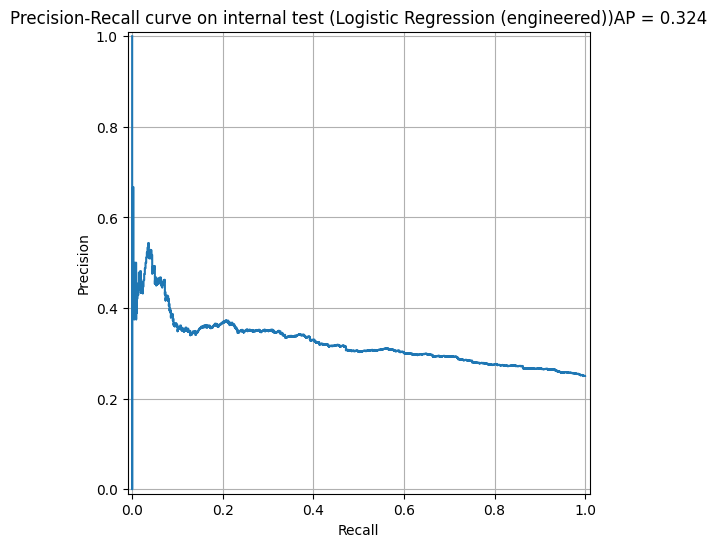

,best_model_family,threshold,f1_test,precision_test,recall_test,roc_auc_test,avg_precision_test
0,Logistic Regression (engineered),0.2,0.4083,0.2796,0.7566,0.5947,0.3241


In [0]:

advanced_best_name = advanced_model_summary.iloc[0]['model_family']
advanced_best_model, advanced_best_thr, advanced_best_test_proba, advanced_best_test_pred = advanced_artifacts[advanced_best_name]

ap_value = average_precision_score(y_test_adv, advanced_best_test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_adv, advanced_best_test_proba)

plt.figure(figsize=(7, 6))
PrecisionRecallDisplay(precision=precision_curve, recall=recall_curve).plot(ax=plt.gca())
plt.title(f'Precision-Recall curve on internal test ({advanced_best_name})AP = {ap_value:.3f}')
plt.show()

pd.DataFrame([{
    'best_model_family': advanced_best_name,
    'threshold': advanced_best_thr,
    'f1_test': f1_score(y_test_adv, advanced_best_test_pred),
    'precision_test': precision_score(y_test_adv, advanced_best_test_pred, zero_division=0),
    'recall_test': recall_score(y_test_adv, advanced_best_test_pred, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, advanced_best_test_proba),
    'avg_precision_test': ap_value
}]).round(4)



## 14.6. Calibration check

Calibration is relevant here because threshold-based decisions depend directly on the quality of predicted probabilities.

The comparison below answers a practical question:

> After calibrating probabilities, does the model become more stable and produce a better F1 / PR balance on the internal test partition?


In [0]:

calibrated_best_model = CalibratedClassifierCV(advanced_best_model, method='sigmoid', cv=3)
calibrated_best_model.fit(X_train_adv, y_train_adv)

valid_proba_cal = calibrated_best_model.predict_proba(X_valid_adv)[:, 1]
cal_threshold_df = evaluate_thresholds_fine(y_valid_adv, valid_proba_cal)
cal_best_thr = float(cal_threshold_df.iloc[0]['threshold'])

test_proba_cal = calibrated_best_model.predict_proba(X_test_adv)[:, 1]
test_pred_cal = (test_proba_cal >= cal_best_thr).astype(int)

calibration_comparison_df = pd.DataFrame([
    {
        'version': 'uncalibrated',
        'threshold': advanced_best_thr,
        'f1_test': f1_score(y_test_adv, advanced_best_test_pred),
        'precision_test': precision_score(y_test_adv, advanced_best_test_pred, zero_division=0),
        'recall_test': recall_score(y_test_adv, advanced_best_test_pred, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_adv, advanced_best_test_proba),
        'avg_precision_test': average_precision_score(y_test_adv, advanced_best_test_proba)
    },
    {
        'version': 'calibrated_sigmoid',
        'threshold': cal_best_thr,
        'f1_test': f1_score(y_test_adv, test_pred_cal),
        'precision_test': precision_score(y_test_adv, test_pred_cal, zero_division=0),
        'recall_test': recall_score(y_test_adv, test_pred_cal, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_adv, test_proba_cal),
        'avg_precision_test': average_precision_score(y_test_adv, test_proba_cal)
    }
]).round(4)

calibration_comparison_df


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run receptive-koi-529 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/c5ed271fcf3b4dd9a1f4d6fcab154d55
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


,version,threshold,f1_test,precision_test,recall_test,roc_auc_test,avg_precision_test
0,uncalibrated,0.2,0.4083,0.2796,0.7566,0.5947,0.3241
1,calibrated_sigmoid,0.2,0.4118,0.2727,0.8407,0.5955,0.3247



## 14.7. Overfitting / underfitting diagnostic with ROC curves for the advanced model

This repeats the original ROC logic but now on the advanced winner.

Interpretation:
- **overfitting**: training ROC clearly much stronger than validation/test;
- **underfitting**: all curves weak and similarly low;
- **healthy generalization**: validation and test remain relatively close to training.


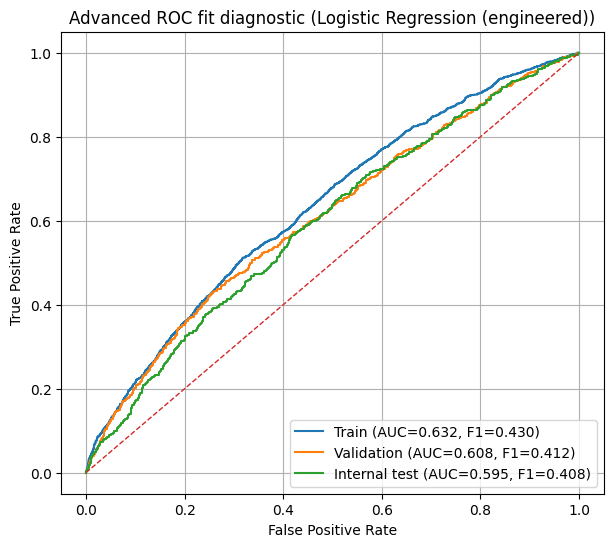

,dataset,threshold,f1,precision,recall,roc_auc
0,Train,0.2,0.4304,0.2954,0.7925,0.6321
1,Validation,0.2,0.4125,0.2831,0.7596,0.6078
2,Internal test,0.2,0.4083,0.2796,0.7566,0.5947


In [0]:

advanced_roc_partitions = {
    'Train': (X_train_adv, y_train_adv),
    'Validation': (X_valid_adv, y_valid_adv),
    'Internal test': (X_test_adv, y_test_adv)
}

advanced_roc_rows = []
plt.figure(figsize=(7, 6))

for split_name, (X_split, y_split) in advanced_roc_partitions.items():
    split_proba = advanced_best_model.predict_proba(X_split)[:, 1]
    split_pred = (split_proba >= advanced_best_thr).astype(int)
    split_auc = roc_auc_score(y_split, split_proba)
    split_f1 = f1_score(y_split, split_pred)

    fpr, tpr, _ = roc_curve(y_split, split_proba)
    plt.plot(fpr, tpr, label=f'{split_name} (AUC={split_auc:.3f}, F1={split_f1:.3f})')

    advanced_roc_rows.append({
        'dataset': split_name,
        'threshold': advanced_best_thr,
        'f1': split_f1,
        'precision': precision_score(y_split, split_pred, zero_division=0),
        'recall': recall_score(y_split, split_pred, zero_division=0),
        'roc_auc': split_auc
    })

plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Advanced ROC fit diagnostic ({advanced_best_name})')
plt.legend(loc='lower right')
plt.show()

advanced_roc_diagnostic_df = pd.DataFrame(advanced_roc_rows).round(4)
advanced_roc_diagnostic_df



## 14.8. Class-balance viability analysis

Because the project is kept in vanilla scikit-learn, class balancing is evaluated through strategies that remain compatible with the current stack:

1. **no balancing**,
2. **class_weight='balanced'**,
3. **manual random undersampling** of the majority class.

### Is balancing viable here?

Yes, but with an important caveat: in this project the main business risk is **too many false positives**. Any balance strategy that raises recall but collapses precision may leave F1 unchanged or even worse.

So the correct criterion is **not whether recall increases**, but whether **F1 and Average Precision improve without making the confusion matrix operationally unacceptable**.


In [0]:

def fit_manual_undersampled_lr(X_train_local, y_train_local, X_reference_local):
    sampled_df = X_train_local.copy()
    sampled_df['_target_temp'] = y_train_local.values

    majority = sampled_df[sampled_df['_target_temp'] == 0]
    minority = sampled_df[sampled_df['_target_temp'] == 1]

    majority_down = resample(
        majority,
        replace=False,
        n_samples=len(minority),
        random_state=RANDOM_STATE
    )

    balanced_df = pd.concat([majority_down, minority], axis=0).sample(frac=1, random_state=RANDOM_STATE)
    X_balanced = balanced_df.drop(columns=['_target_temp'])
    y_balanced = balanced_df['_target_temp']

    pipe = make_pipeline_from_frame(
        LogisticRegression(max_iter=3000, C=0.1, class_weight=None, random_state=RANDOM_STATE),
        X_balanced,
        scale_numeric=True
    )
    pipe.fit(X_balanced, y_balanced)

    reference_proba = pipe.predict_proba(X_reference_local)[:, 1]
    return pipe, reference_proba


balance_rows = []

# A) No balancing
lr_none = make_pipeline_from_frame(
    LogisticRegression(max_iter=3000, C=0.1, class_weight=None, random_state=RANDOM_STATE),
    X_train_adv,
    scale_numeric=True
)
lr_none.fit(X_train_adv, y_train_adv)
valid_proba_none = lr_none.predict_proba(X_valid_adv)[:, 1]
thr_none = float(evaluate_thresholds_fine(y_valid_adv, valid_proba_none).iloc[0]['threshold'])
test_proba_none = lr_none.predict_proba(X_test_adv)[:, 1]
test_pred_none = (test_proba_none >= thr_none).astype(int)
balance_rows.append({
    'strategy': 'none',
    'threshold': thr_none,
    'f1_test': f1_score(y_test_adv, test_pred_none),
    'precision_test': precision_score(y_test_adv, test_pred_none, zero_division=0),
    'recall_test': recall_score(y_test_adv, test_pred_none, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, test_proba_none),
    'avg_precision_test': average_precision_score(y_test_adv, test_proba_none)
})

# B) Class weight balanced
lr_balanced = make_pipeline_from_frame(
    LogisticRegression(max_iter=3000, C=0.1, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_adv,
    scale_numeric=True
)
lr_balanced.fit(X_train_adv, y_train_adv)
valid_proba_balanced = lr_balanced.predict_proba(X_valid_adv)[:, 1]
thr_balanced = float(evaluate_thresholds_fine(y_valid_adv, valid_proba_balanced).iloc[0]['threshold'])
test_proba_balanced = lr_balanced.predict_proba(X_test_adv)[:, 1]
test_pred_balanced = (test_proba_balanced >= thr_balanced).astype(int)
balance_rows.append({
    'strategy': 'class_weight_balanced',
    'threshold': thr_balanced,
    'f1_test': f1_score(y_test_adv, test_pred_balanced),
    'precision_test': precision_score(y_test_adv, test_pred_balanced, zero_division=0),
    'recall_test': recall_score(y_test_adv, test_pred_balanced, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, test_proba_balanced),
    'avg_precision_test': average_precision_score(y_test_adv, test_proba_balanced)
})

# C) Manual random undersampling
lr_under, valid_proba_under = fit_manual_undersampled_lr(X_train_adv, y_train_adv, X_valid_adv)
thr_under = float(evaluate_thresholds_fine(y_valid_adv, valid_proba_under).iloc[0]['threshold'])
test_proba_under = lr_under.predict_proba(X_test_adv)[:, 1]
test_pred_under = (test_proba_under >= thr_under).astype(int)
balance_rows.append({
    'strategy': 'manual_random_undersampling',
    'threshold': thr_under,
    'f1_test': f1_score(y_test_adv, test_pred_under),
    'precision_test': precision_score(y_test_adv, test_pred_under, zero_division=0),
    'recall_test': recall_score(y_test_adv, test_pred_under, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, test_proba_under),
    'avg_precision_test': average_precision_score(y_test_adv, test_proba_under)
})

balance_viability_df = pd.DataFrame(balance_rows).sort_values(['f1_test', 'avg_precision_test'], ascending=False).reset_index(drop=True)
balance_viability_df.round(4)


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run industrious-wren-670 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/180f2c7acfc44da49612e8924186cb94
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run puzzled-trout-212 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/c6886e30a2514999924249db03e64e7b
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run thundering-rook-73 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372/runs/6342b5ff387642d5955716b0370e907e
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/2127106661478372


,strategy,threshold,f1_test,precision_test,recall_test,roc_auc_test,avg_precision_test
0,none,0.20,0.4092,0.2803,0.7581,0.5950,0.3243
1,manual_random_undersampling,0.37,0.4088,0.2654,0.8894,0.5865,0.3132
2,class_weight_balanced,0.43,0.4075,0.2797,0.7507,0.5949,0.3242



## 14.9. Final advanced confusion matrix

This cell visualizes the confusion matrix of the best advanced setup. It should be interpreted together with F1, Average Precision, and the balance strategy results.

A model is only practically preferable if its gains in F1/AP do not come from an unacceptable explosion in false positives.


final_advanced_model,threshold,f1_test,precision_test,recall_test,roc_auc_test,avg_precision_test
Logistic Regression (engineered) + calibration,0.2,0.4118,0.2727,0.8407,0.5955,0.3247


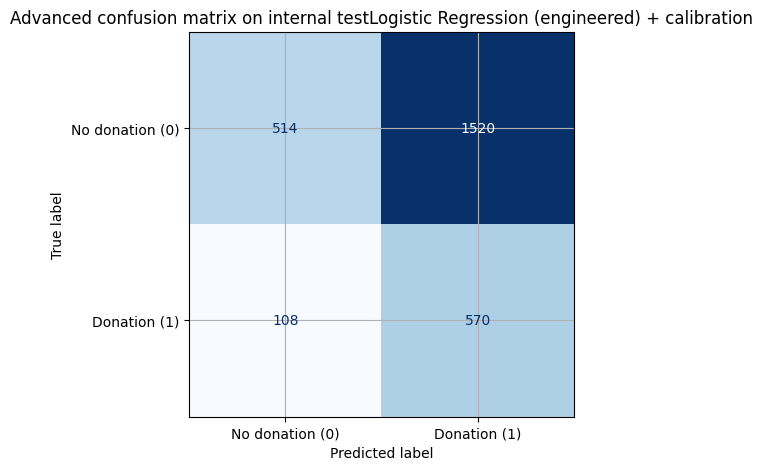

In [0]:

final_advanced_name = advanced_best_name
final_advanced_thr = advanced_best_thr
final_advanced_proba = advanced_best_test_proba
final_advanced_pred = advanced_best_test_pred

# If calibration outperforms the uncalibrated version on F1, switch the final advanced view.
if calibration_comparison_df.sort_values(['f1_test', 'avg_precision_test'], ascending=False).iloc[0]['version'] == 'calibrated_sigmoid':
    final_advanced_name = f'{advanced_best_name} + calibration'
    final_advanced_thr = cal_best_thr
    final_advanced_proba = test_proba_cal
    final_advanced_pred = test_pred_cal

final_advanced_results_df = pd.DataFrame([{
    'final_advanced_model': final_advanced_name,
    'threshold': final_advanced_thr,
    'f1_test': f1_score(y_test_adv, final_advanced_pred),
    'precision_test': precision_score(y_test_adv, final_advanced_pred, zero_division=0),
    'recall_test': recall_score(y_test_adv, final_advanced_pred, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test_adv, final_advanced_proba),
    'avg_precision_test': average_precision_score(y_test_adv, final_advanced_proba)
}]).round(4)

display(final_advanced_results_df)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_adv,
    final_advanced_pred,
    display_labels=['No donation (0)', 'Donation (1)'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title(f'Advanced confusion matrix on internal test{final_advanced_name}')
plt.show()
